# Group 6 Project: Forest Classification
This notebook pulls together models and tuning by :
- Julie Huynh
- Jingda Li
- Jane Sanchez
- Jesse Donelle
- Jeremy May

The machine learning models were executed on macOS 26.5.2 using an Apple ARM64 system with 8 CPU cores and 16 GB of RAM. The Python environment used Anaconda Python 3.13.5 with NumPy 2.1.3, Pandas 2.2.3, scikit-learn 1.9.0, and TensorFlow 2.21.0. TensorFlow detected only the CPU, so the neural network models were trained without GPU acceleration.


In [1]:
# Source: group-project-jane.ipynb Cell 2, group-project-jer.ipynb Cell 2,
# group-project-jane-neural.ipynb Cell 2, group_project_Julie.ipynb Cell 1,
# JESSY_Forest_CoverType_Logistic_Regression_Analysis_Balanced.ipynb Cell 3
import kagglehub
import json
import re
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras 
from keras import backend as K
from keras import layers


%matplotlib inline
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print(tf.keras.__version__)


3.15.0


## Helper Functions

In [2]:
# Cache directories for trained models and derived results.
CACHE_ROOT = Path("cache")
MODEL_CACHE_DIR = CACHE_ROOT / "models"
RESULTS_CACHE_DIR = CACHE_ROOT / "results"
for _d in (MODEL_CACHE_DIR, RESULTS_CACHE_DIR):
    _d.mkdir(parents=True, exist_ok=True)


def _slugify(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


def _cache_path(directory: Path, cache_key: str, suffix: str) -> Path:
    return directory / f"{_slugify(cache_key)}{suffix}"


def _load_or_build(path: Path, build_fn, load_fn, save_fn, label: str):
    if path.exists():
        print(f"[cache] loading {label}: {path}")
        return load_fn(path)
    obj = build_fn()
    save_fn(obj, path)
    print(f"[cache] saved {label}: {path}")
    return obj


def _load_or_fit_joblib(cache_key, estimator_like, X_fit, y_fit, label):
    path = _cache_path(MODEL_CACHE_DIR, cache_key, ".joblib")
    return _load_or_build(
        path,
        lambda: estimator_like.fit(X_fit, y_fit),
        joblib.load,
        joblib.dump,
        label,
    )


def _save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def _load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def _result_json_path(cache_key: str, suffix: str) -> Path:
    return _cache_path(RESULTS_CACHE_DIR, f"{cache_key}_{suffix}", ".json")


def _save_result_json(cache_key: str, suffix: str, payload, label: str):
    out_path = _result_json_path(cache_key, suffix)
    _save_json(payload, out_path)
    print(f"[cache] saved {label}: {out_path}")


def _load_or_predict(cache_key, estimator, X_pred):
    pred_path = _cache_path(RESULTS_CACHE_DIR, cache_key, ".npy")
    if pred_path.exists():
        cached = np.load(pred_path, allow_pickle=False)
        if len(cached) == len(X_pred):
            print(f"[cache] loading predictions: {pred_path}")
            return cached
        print(f"[cache] prediction length mismatch, recomputing: {cache_key}")

    y_pred = estimator.predict(X_pred)
    np.save(pred_path, y_pred)
    print(f"[cache] saved predictions: {pred_path}")
    return y_pred


print(f"Model cache: {MODEL_CACHE_DIR.resolve()}")
print(f"Result cache: {RESULTS_CACHE_DIR.resolve()}")

Model cache: /Users/janesanchez/Library/Mobile Documents/com~apple~CloudDocs/PYTHON/Machine Learning/group6-ml-project/cache/models
Result cache: /Users/janesanchez/Library/Mobile Documents/com~apple~CloudDocs/PYTHON/Machine Learning/group6-ml-project/cache/results


In [3]:
# Source: group-project.ipynb Cell 3, group-project-jane.ipynb Cell 5,
# group-project-jer.ipynb Cell 3
path = kagglehub.dataset_download("uciml/forest-cover-type-dataset")
print("Dataset downloaded to:", path)

# Find the CSV file
csv_path = Path(path) / "covtype.csv"

# Load into DataFrame
covtype_df = pd.read_csv(csv_path)

display(covtype_df.head())
print(covtype_df.info())

labels = np.arange(1, 8).tolist()
forest_cover_types = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz",
]
label_name_map = dict(zip(labels, forest_cover_types))

# Keep class colors consistent across all class-based charts.
palette_list = sns.color_palette("deep", len(labels))
class_color_map = dict(zip(labels, palette_list))

display(label_name_map)
print(covtype_df["Cover_Type"].value_counts())

Dataset downloaded to: /Users/janesanchez/.cache/kagglehub/datasets/uciml/forest-cover-type-dataset/versions/1


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

{1: 'Spruce/Fir',
 2: 'Lodgepole Pine',
 3: 'Ponderosa Pine',
 4: 'Cottonwood/Willow',
 5: 'Aspen',
 6: 'Douglas-fir',
 7: 'Krummholz'}

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


In [4]:
# Source: group-project.ipynb Cell 5, group-project-jer.ipynb Cell 7,
# JESSY_Forest_CoverType_Logistic_Regression_Analysis_Balanced.ipynb Cells 14 and 18
X = covtype_df.drop(columns=["Cover_Type"])
y = covtype_df["Cover_Type"]

continuous_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
binary_features = [c for c in X.columns if c not in continuous_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# For TSNE, SVC RBF & Learning Curve
sample_size = 100000
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=sample_size,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_features),
        ("binary", "passthrough", binary_features),
    ]
)

X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)
y_train_nn = y_train.to_numpy() - 1
y_test_nn = y_test.to_numpy() - 1

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(464809, 54) (116203, 54)
Cover_Type
2    226640
1    169472
3     28603
7     16408
6     13894
5      7594
4      2198
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)
Shared data profiling and class-overlap visualizations from Jane and Julie notebooks.

### EDA: Data Quality and Class Distribution
Missing values, target balance, and descriptive statistics.

Missing values: 0


Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

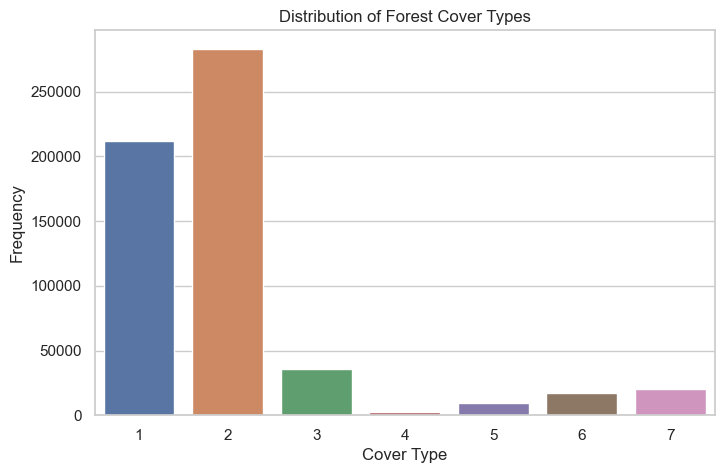

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [5]:
# Source: group_project_Julie.ipynb Cell 5, group-project-jane.ipynb Cells 6 and 8
print("Missing values:", covtype_df.isna().sum().sum())
class_counts = y.value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=labels, hue=y, palette=class_color_map, legend=False)
plt.title("Distribution of Forest Cover Types")
plt.xlabel("Cover Type")
plt.ylabel("Frequency")
plt.show()

display(covtype_df.describe())

### EDA: Correlation and Continuous Feature Signal
Correlation heatmap and ANOVA F-score ranking for continuous/overall predictors.

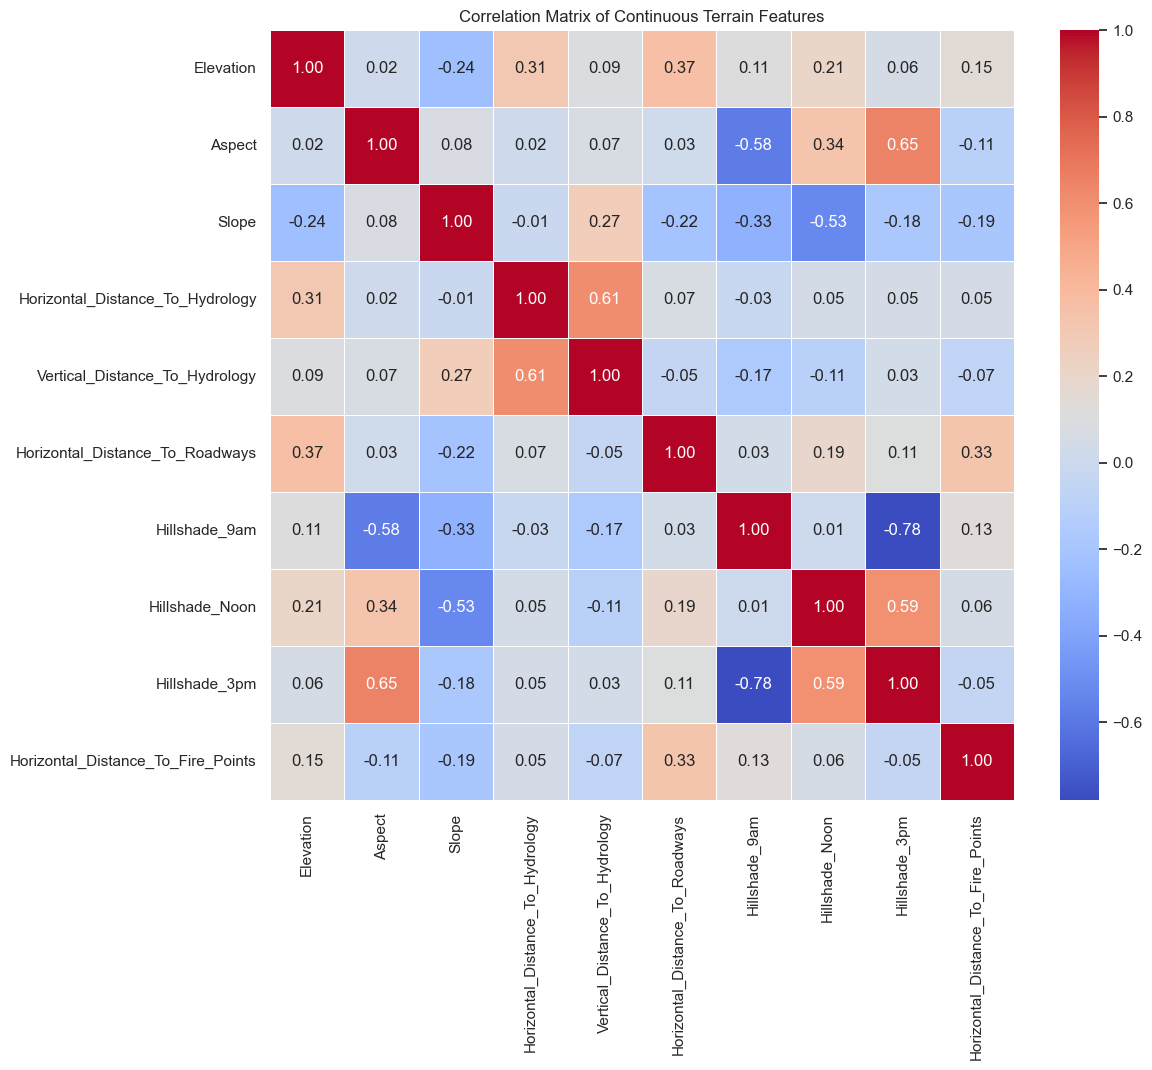

,F,p
Aspect,446.717061,0.000000e+00
Elevation,155306.869021,0.000000e+00
Hillshade_3pm,1042.196255,0.000000e+00
Hillshade_9am,3231.992007,0.000000e+00
Hillshade_Noon,2920.383824,0.000000e+00
Horizontal_Distance_To_Fire_Points,7262.064444,0.000000e+00
Horizontal_Distance_To_Hydrology,2364.952074,0.000000e+00
Horizontal_Distance_To_Roadways,10275.781727,0.000000e+00
Slope,7762.474223,0.000000e+00
Soil_Type1,5131.597085,0.000000e+00


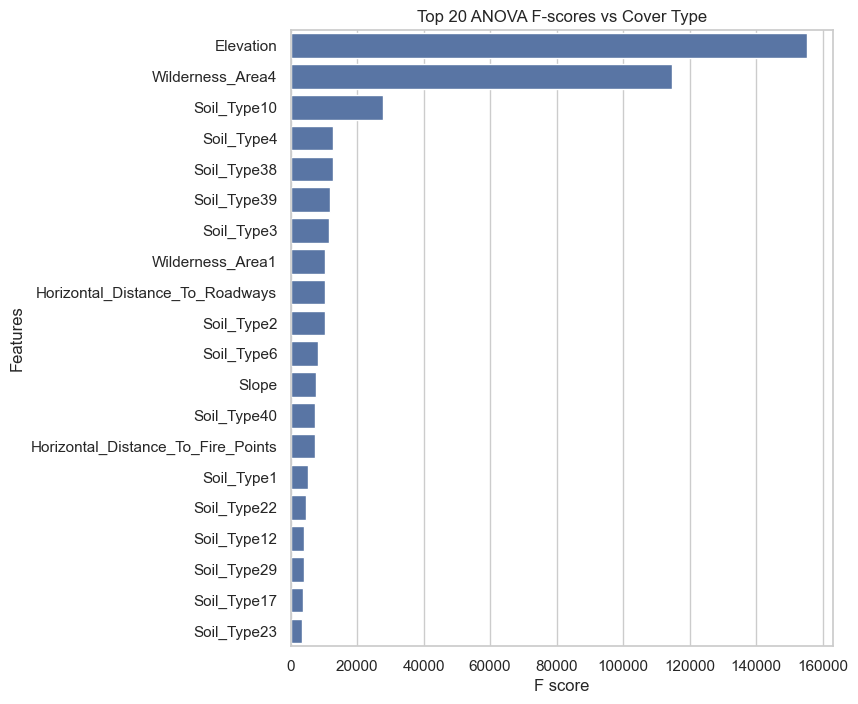

In [6]:
# Source: group-project-jane.ipynb Cells 9 and 10, group_project_Julie.ipynb Cell 8
corr = X[continuous_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Continuous Terrain Features")
plt.show()

target = np.asarray(y).ravel()
f_vals, p_vals = f_classif(X, target)
f_series = pd.Series(f_vals, index=X.columns).sort_values(ascending=False)
display(pd.DataFrame({"F": f_series, "p": pd.Series(p_vals, index=X.columns)}).head(20))

plt.figure(figsize=(7, 8))
sns.barplot(x=f_series.values[:20], y=f_series.index[:20])
plt.xlabel("F score")
plt.ylabel("Features")
plt.title("Top 20 ANOVA F-scores vs Cover Type")
plt.show()

### EDA: Tree-Based Feature Importance
Quick shallow-tree importance check and elevation-by-class boxplot.

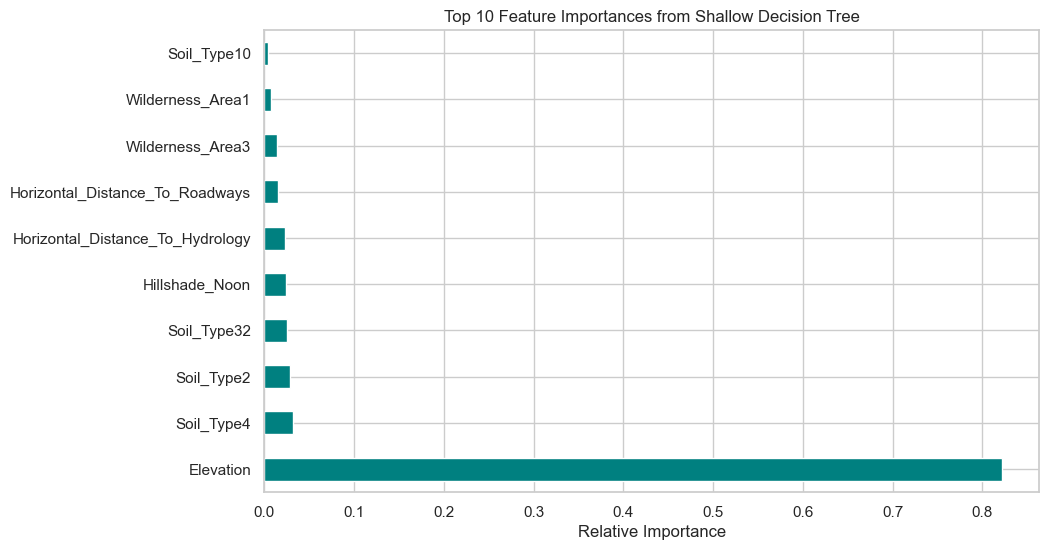

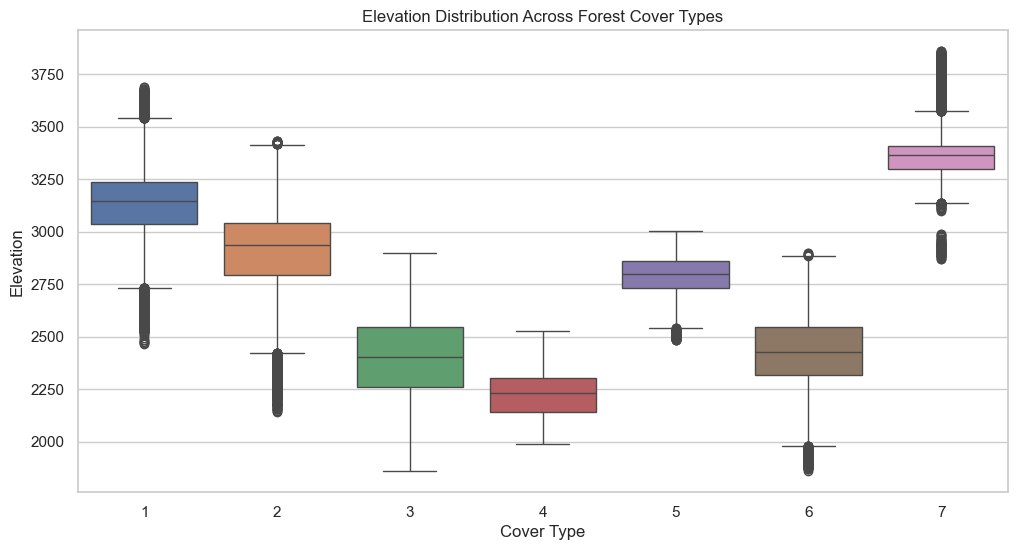

In [7]:
# Source: group_project_Julie.ipynb Cells 10 and 11
base_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
base_tree.fit(X_train, y_train)
importances = pd.Series(base_tree.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances from Shallow Decision Tree")
plt.xlabel("Relative Importance")
plt.show()

train_df = X_train.copy()
train_df["Cover_Type"] = y_train
plt.figure(figsize=(12, 6))
sns.boxplot(x="Cover_Type", y="Elevation", data=train_df, order=labels, hue="Cover_Type", palette=class_color_map, legend=False)
plt.title("Elevation Distribution Across Forest Cover Types")
plt.xlabel("Cover Type")
plt.ylabel("Elevation")
plt.show()

### EDA: Binary Feature Engineering for Overlap Analysis
Prepare soil and wilderness feature groupings for prevalence and association checks.

In [8]:
# Source: group-project-jane.ipynb Cells 12 and 13 (soil/wilderness EDA prep)
soil_cols = [c for c in X.columns if c.startswith("Soil_Type")]
wilderness_cols = [c for c in X.columns if c.startswith("Wilderness_Area")]
binary_features = soil_cols + wilderness_cols

covtype_eda = X.copy()
covtype_eda["Cover_Type"] = y
covtype_eda["SoilType"] = (
    covtype_eda[soil_cols].idxmax(axis=1).str.replace("Soil_Type", "", regex=False).astype(int)
)
covtype_eda["WildernessArea"] = (
    covtype_eda[wilderness_cols].idxmax(axis=1).str.replace("Wilderness_Area", "", regex=False).astype(int)
)

print("Prepared soil/wilderness EDA frame:", covtype_eda.shape)
print("Binary feature count:", len(binary_features))

Prepared soil/wilderness EDA frame: (581012, 57)
Binary feature count: 44


### EDA: Soil and Wilderness Pattern Overlap
Soil prevalence heatmap, wilderness prevalence chart, and chi-square / mutual-information ranking.

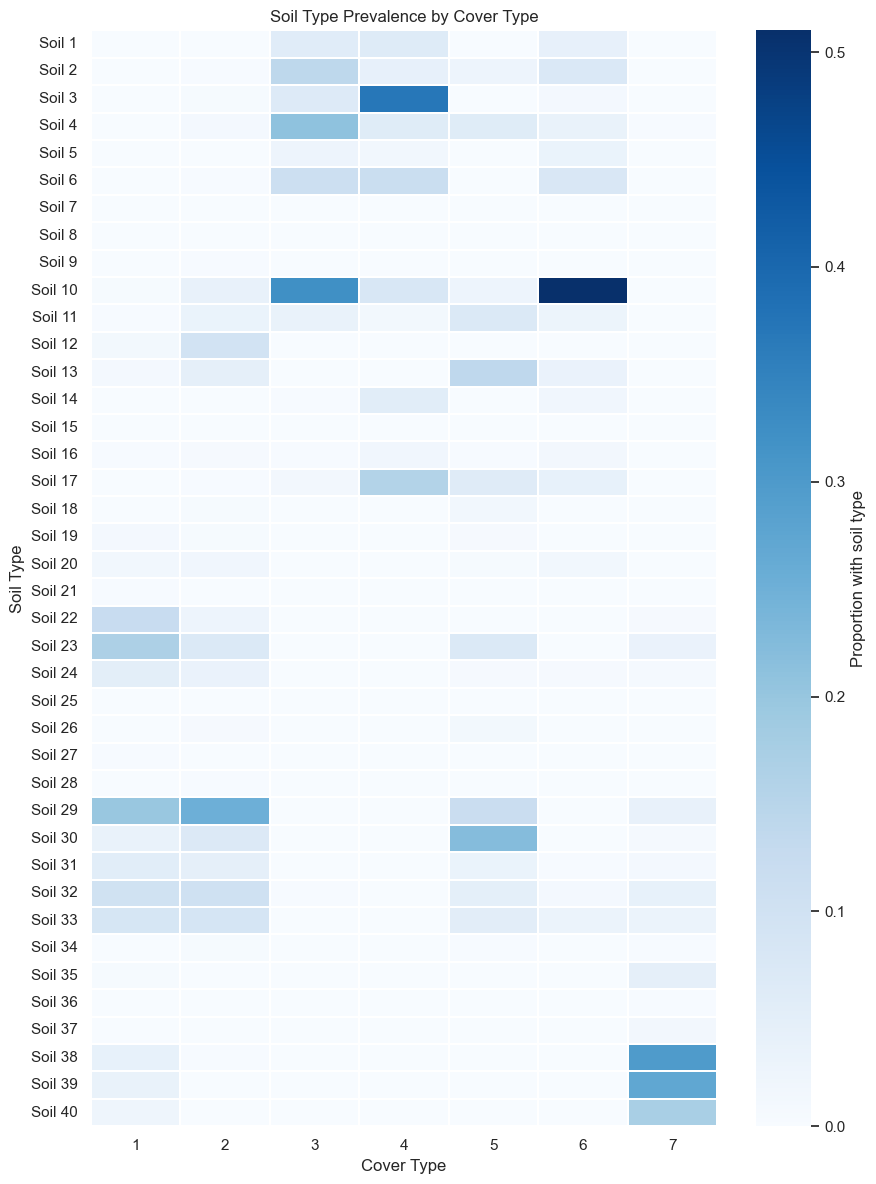

In [9]:
# Source: group-project-jane.ipynb Cell 12 (soil prevalence heatmap)
soil_prevalence = covtype_eda.groupby("Cover_Type")[soil_cols].mean().T
soil_prevalence.index = soil_prevalence.index.str.replace("Soil_Type", "Soil ", regex=False)

plt.figure(figsize=(9, 12))
sns.heatmap(
    soil_prevalence,
    cmap="Blues",
    cbar_kws={"label": "Proportion with soil type"},
    linewidths=0.2,
)
plt.title("Soil Type Prevalence by Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Soil Type")
plt.tight_layout()
plt.show()

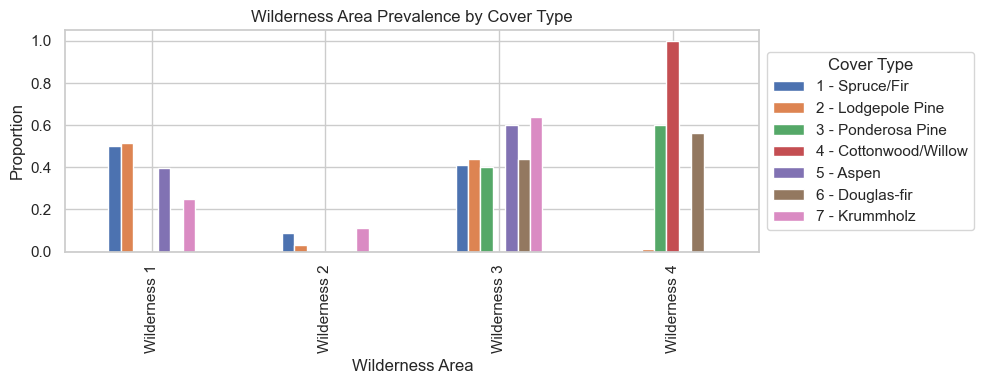

,Feature,Chi2,Mutual Information
43,Wilderness_Area4,294909.236042,0.148157
40,Wilderness_Area1,30998.839431,0.104735
9,Soil_Type10,121906.779172,0.063103
28,Soil_Type29,18113.053448,0.036925
42,Wilderness_Area3,4112.544320,0.034747
37,Soil_Type38,65694.581044,0.030848
38,Soil_Type39,62122.857979,0.028014
3,Soil_Type4,66379.063031,0.027673
21,Soil_Type22,24681.268046,0.025585
11,Soil_Type12,21609.430494,0.025307


In [10]:
# Source: group-project-jane.ipynb Cells 13 and 14 (wilderness prevalence + chi2/MI)
wilderness_prevalence = covtype_eda.groupby("Cover_Type")[wilderness_cols].mean().T
wilderness_prevalence.index = wilderness_prevalence.index.str.replace("Wilderness_Area", "Wilderness ", regex=False)

ax = wilderness_prevalence.plot(kind="bar", figsize=(10, 4), color=palette_list)
ax.set_ylabel("Proportion")
ax.set_xlabel("Wilderness Area")
ax.set_title("Wilderness Area Prevalence by Cover Type")
ax.legend(
    [f"{i} - {label_name_map[i]}" for i in labels],
    title="Cover Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
plt.tight_layout()
plt.show()

chi2_vals, _ = chi2(covtype_eda[binary_features], covtype_eda["Cover_Type"])
mi_vals = mutual_info_classif(covtype_eda[binary_features], covtype_eda["Cover_Type"], random_state=RANDOM_STATE)

binary_scores = pd.DataFrame({
    "Feature": binary_features,
    "Chi2": chi2_vals,
    "Mutual Information": mi_vals,
}).sort_values("Mutual Information", ascending=False)

display(binary_scores.head(20))

### EDA: LDA Projection
Linear discriminant projection to visualize class separability in 2D.

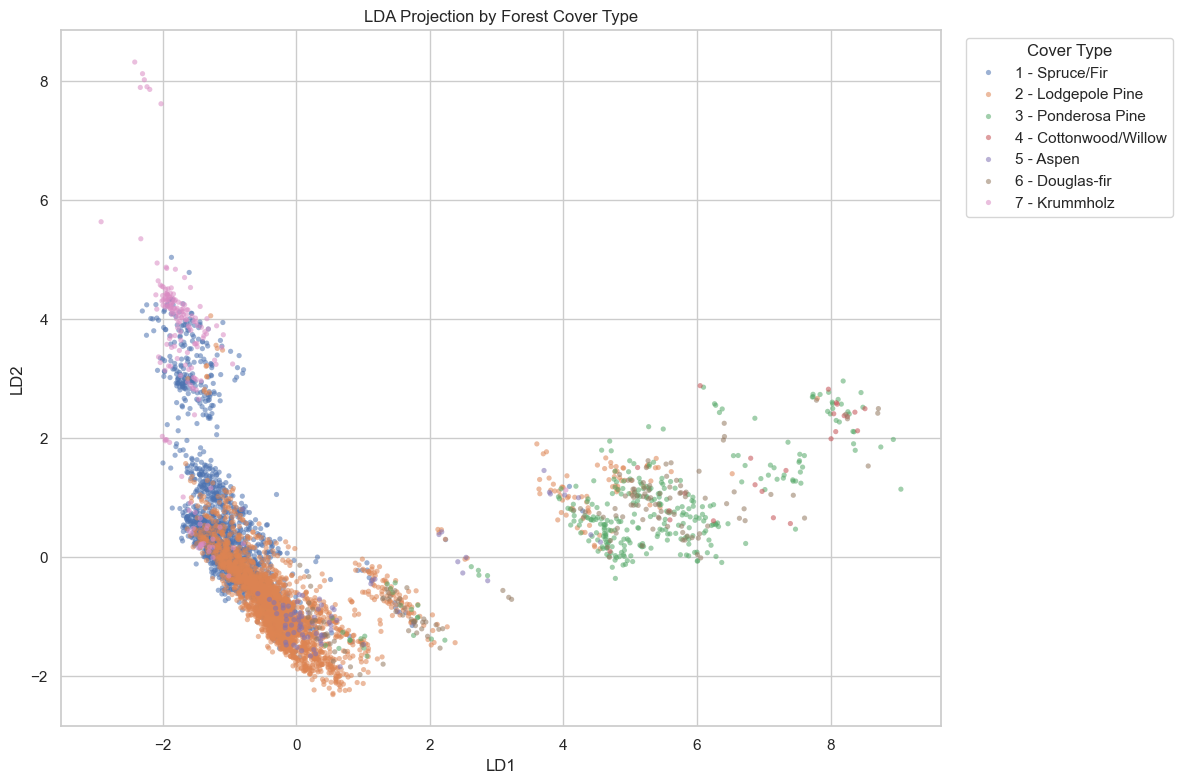

In [11]:
# Source: group-project-jane.ipynb Cell 27 (LDA visualization), adapted to shared notebook flow
lda_sample_size = 5000
lda_sample_idx = y_train.groupby(y_train, group_keys=False).apply(
    lambda s: s.sample(max(1, int(round(len(s) / len(y_train) * lda_sample_size))), random_state=RANDOM_STATE)
).index

X_lda_sample = X_train.loc[lda_sample_idx]
y_lda_sample = y_train.loc[lda_sample_idx]

X_lda_scaled = StandardScaler().fit_transform(X_lda_sample)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_lda_scaled, y_lda_sample)

lda_plot_df = pd.DataFrame({
    "LD1": X_lda[:, 0],
    "LD2": X_lda[:, 1],
    "Cover_Type": y_lda_sample.values,
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=lda_plot_df,
    x="LD1",
    y="LD2",
    hue="Cover_Type",
    hue_order=labels,
    palette=class_color_map,
    s=14,
    alpha=0.55,
    linewidth=0,
)

handles, legend_labels = plt.gca().get_legend_handles_labels()
mapped_labels = []
for lab in legend_labels:
    try:
        i = int(float(lab))
        mapped_labels.append(f"{i} - {label_name_map[i]}")
    except Exception:
        mapped_labels.append(lab)

plt.legend(handles=handles, labels=mapped_labels, title="Cover Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("LDA Projection by Forest Cover Type")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.tight_layout()
plt.show()

### EDA: t-SNE Projection 
Nonlinear 2D embedding to inspect local neighborhood overlap between classes.

t-SNE sample size: 100,000
[cache] saved t-SNE pipeline: cache/models/tsne_pipeline_balanced_sample.joblib
[cache] saved t-SNE embedding: cache/results/tsne_embedding_balanced_sample.npy


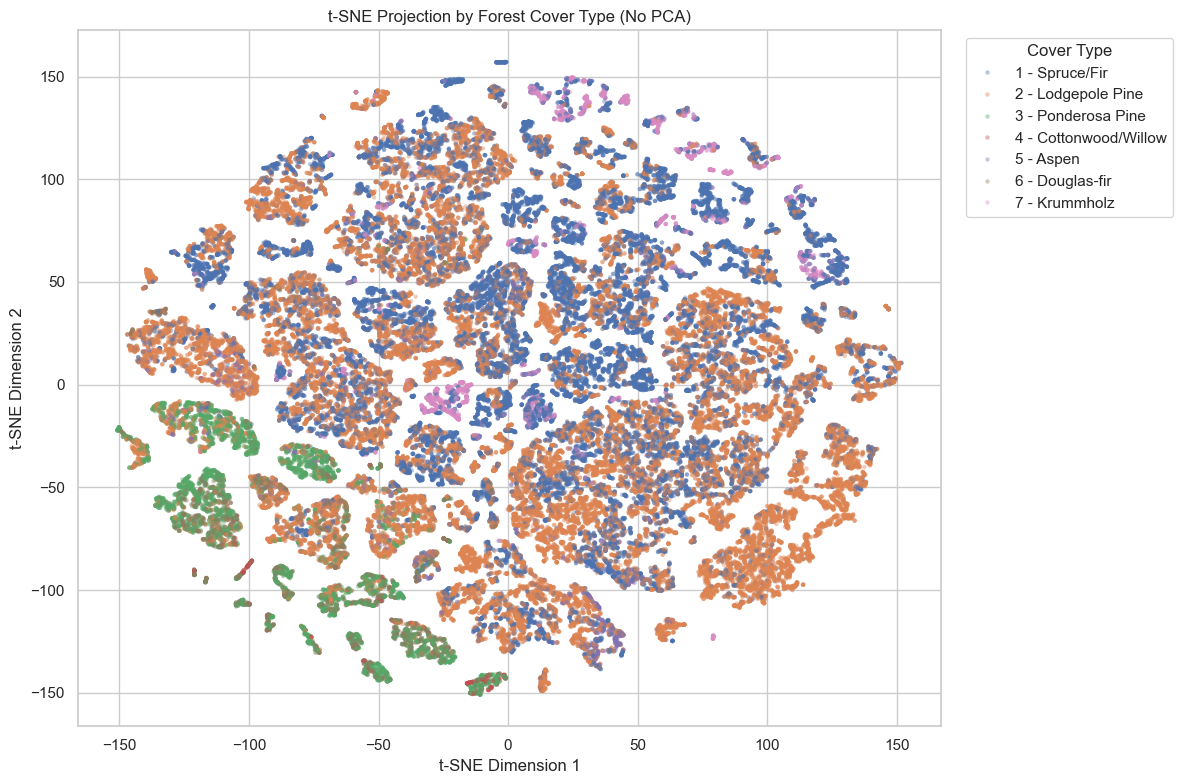

Note: t-SNE preserves local neighborhoods; global distances are less interpretable.


In [12]:
# Source: group-project-jane.ipynb Cells 17 and 18 (t-SNE), adapted with NO PCA
# Increase sample size for a denser visualization while preserving class balance.
tsne_sample_size = min(100000, len(y_train))

if tsne_sample_size < len(y_train):
    X_tsne_sample, _, y_tsne_sample, _ = train_test_split(
        X_train,
        y_train,
        train_size=tsne_sample_size,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_tsne_sample = X_train.copy()
    y_tsne_sample = y_train.copy()

print(f"t-SNE sample size: {len(X_tsne_sample):,}")

tsne_pipeline_cache_key = "tsne_pipeline_balanced_sample"
tsne_embed_path = _cache_path(RESULTS_CACHE_DIR, "tsne_embedding_balanced_sample", ".npy")
tsne_index_path = _cache_path(RESULTS_CACHE_DIR, "tsne_embedding_balanced_sample_index", ".npy")
sample_index = X_tsne_sample.index.to_numpy()

cached_ok = tsne_embed_path.exists() and tsne_index_path.exists()
if cached_ok:
    cached_index = np.load(tsne_index_path, allow_pickle=False)
    cached_ok = np.array_equal(cached_index, sample_index)

if cached_ok:
    tsne_pipeline = joblib.load(_cache_path(MODEL_CACHE_DIR, tsne_pipeline_cache_key, ".joblib"))
    X_tsne = np.load(tsne_embed_path, allow_pickle=False)
    print(f"[cache] loading t-SNE pipeline and embedding: {tsne_embed_path}")
else:
    tsne_pipeline = Pipeline([
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=30, random_state=42)),
        ('tsne',    TSNE(n_components=2, perplexity=30, max_iter=1200, random_state=42)),
    ])

    X_tsne = tsne_pipeline.fit_transform(X_tsne_sample)
    joblib.dump(tsne_pipeline, _cache_path(MODEL_CACHE_DIR, tsne_pipeline_cache_key, ".joblib"))
    np.save(tsne_embed_path, X_tsne)
    np.save(tsne_index_path, sample_index)
    print(f"[cache] saved t-SNE pipeline: {_cache_path(MODEL_CACHE_DIR, tsne_pipeline_cache_key, '.joblib')}")
    print(f"[cache] saved t-SNE embedding: {tsne_embed_path}")

tsne_plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Cover_Type": y_tsne_sample.values,
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_plot_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cover_Type",
    hue_order=labels,
    palette=class_color_map,
    s=10,
    alpha=0.4,
    linewidth=0,
)

handles, legend_labels = plt.gca().get_legend_handles_labels()
mapped_labels = []
for lab in legend_labels:
    try:
        i = int(float(lab))
        mapped_labels.append(f"{i} - {label_name_map[i]}")
    except Exception:
        mapped_labels.append(lab)

plt.legend(handles=handles, labels=mapped_labels, title="Cover Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("t-SNE Projection by Forest Cover Type (No PCA)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Note: t-SNE preserves local neighborhoods; global distances are less interpretable.")

## Model Evaluation Framework
Common evaluation helper used by all model sections (classification report, confusion matrix, normalized confusion matrix, and summary metrics).

In [13]:
# Source: integrated from group-project-jer.ipynb Cell 11 and Jessy balanced cells
def evaluate_predictions(model_name, y_true, y_pred, labels_numeric, target_names, summary_rows):
    print(f"=== {model_name} :: Classification Report ===")
    print(classification_report(y_true, y_pred, labels=labels_numeric, target_names=target_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels_numeric)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    cm_norm = confusion_matrix(y_true, y_pred, labels=labels_numeric, normalize="true")
    ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=target_names).plot(cmap="Blues", xticks_rotation=45, values_format=".1%")
    plt.title(f"{model_name} Normalized Confusion Matrix")
    plt.show()

    summary_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    })

model_summaries = []

## Model Type: Logistic Regression
Balanced multinomial logistic regression baseline from Jessy's tuned workflow.

[cache] saved estimator: cache/models/logistic_regression_unbalanced.joblib
[cache] saved predictions: cache/results/logistic_regression_unbalanced.npy
=== LogisticRegression class_weight=None :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.7109    0.6972    0.7040     42368
   Lodgepole Pine     0.7463    0.7999    0.7722     56661
   Ponderosa Pine     0.6787    0.8018    0.7351      7151
Cottonwood/Willow     0.6103    0.4335    0.5069       549
            Aspen     0.1406    0.0047    0.0092      1899
      Douglas-fir     0.4961    0.2741    0.3531      3473
        Krummholz     0.7357    0.5570    0.6340      4102

         accuracy                         0.7235    116203
        macro avg     0.5884    0.5098    0.5306    116203
     weighted avg     0.7109    0.7235    0.7139    116203



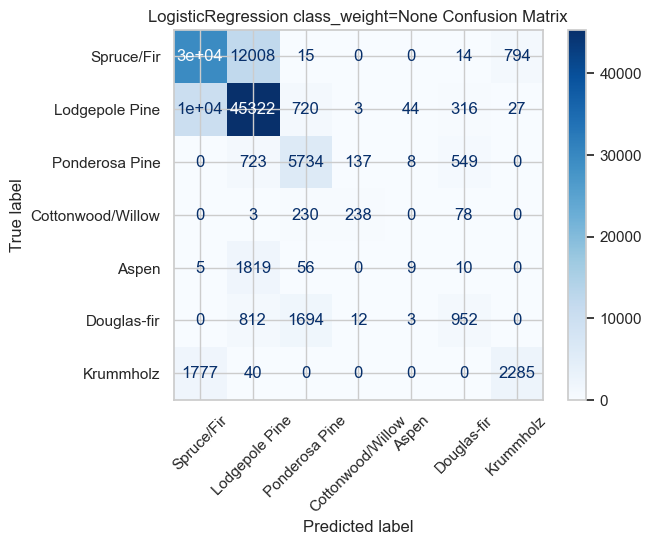

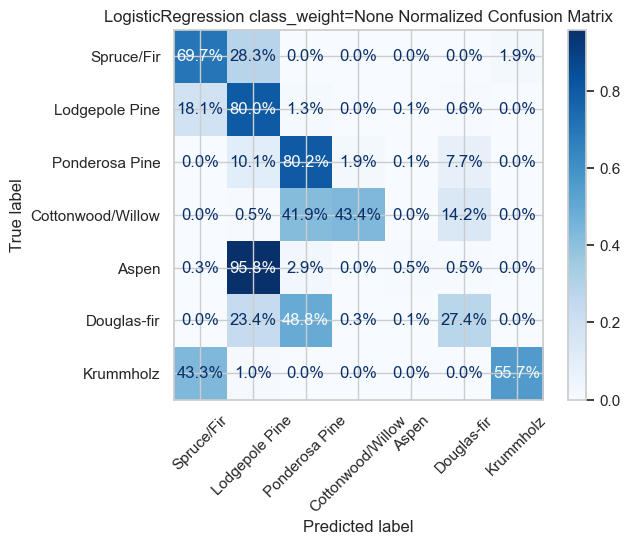

[cache] saved estimator: cache/models/logistic_regression_balanced.joblib
[cache] saved predictions: cache/results/logistic_regression_balanced.npy
=== LogisticRegression class_weight=balanced :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.6807    0.6636    0.6720     42368
   Lodgepole Pine     0.7895    0.5215    0.6281     56661
   Ponderosa Pine     0.6998    0.5636    0.6243      7151
Cottonwood/Willow     0.2890    0.8871    0.4360       549
            Aspen     0.1039    0.7788    0.1833      1899
      Douglas-fir     0.3392    0.6602    0.4481      3473
        Krummholz     0.4044    0.8901    0.5561      4102

         accuracy                         0.5990    116203
        macro avg     0.4724    0.7093    0.5069    116203
     weighted avg     0.7037    0.5990    0.6278    116203



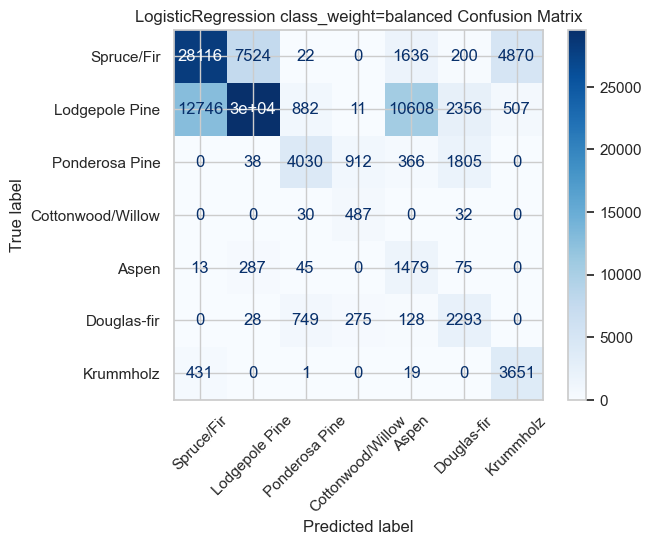

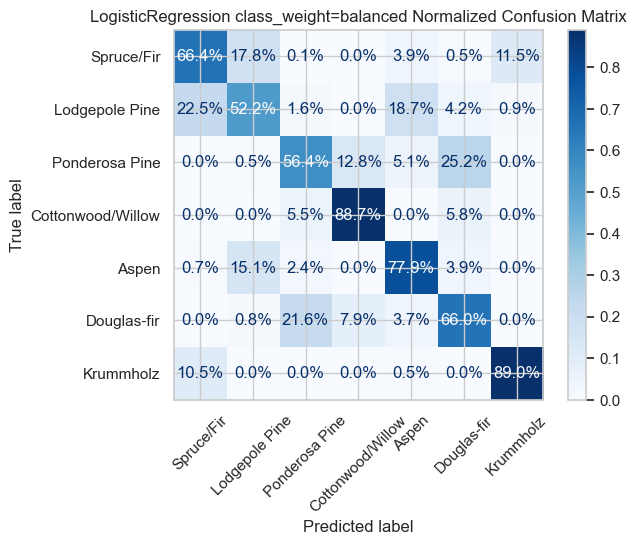

In [14]:
# Source: JESSY_Forest_CoverType_Logistic_Regression_Analysis_Balanced.ipynb Cells 22 to 31
logistic_model_unbalanced = _load_or_fit_joblib(
    "logistic_regression_unbalanced",
    Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                LogisticRegression(
                    solver="saga",
                    # penalty="l2", (default)
                    # C=1.0, (default)
                    max_iter=500,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    X_train,
    y_train,
    "estimator",
 )
y_pred_log_un = _load_or_predict("logistic_regression_unbalanced", logistic_model_unbalanced, X_test)
evaluate_predictions("LogisticRegression class_weight=None", y_test, y_pred_log_un, labels, forest_cover_types, model_summaries)

logistic_model = _load_or_fit_joblib(
    "logistic_regression_balanced",
    Pipeline([
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                # solver="lbfgs", (default)
                # penalty="l2", (default)
                # C=1.0, (default)
                class_weight="balanced",
                max_iter=500,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
    X_train,
    y_train,
    "estimator",
 )
y_pred_log = _load_or_predict("logistic_regression_balanced", logistic_model, X_test)
evaluate_predictions("LogisticRegression class_weight=balanced", y_test, y_pred_log, labels, forest_cover_types, model_summaries)
# execution time 5.7s

## Model Type: Linear SVM
LinearSVC comparison with unweighted and class-weight-balanced settings.

[cache] saved estimator: cache/models/linear_svc_unweighted.joblib
[cache] saved predictions: cache/results/linear_svc_unweighted.npy
=== LinearSVC class_weight=None :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.7070    0.6825    0.6945     42368
   Lodgepole Pine     0.7350    0.7966    0.7646     56661
   Ponderosa Pine     0.6105    0.8663    0.7162      7151
Cottonwood/Willow     0.6201    0.2022    0.3049       549
            Aspen     0.5581    0.0126    0.0247      1899
      Douglas-fir     0.4307    0.0573    0.1011      3473
        Krummholz     0.6821    0.5090    0.5830      4102

         accuracy                         0.7114    116203
        macro avg     0.6205    0.4467    0.4556    116203
     weighted avg     0.7027    0.7114    0.6956    116203



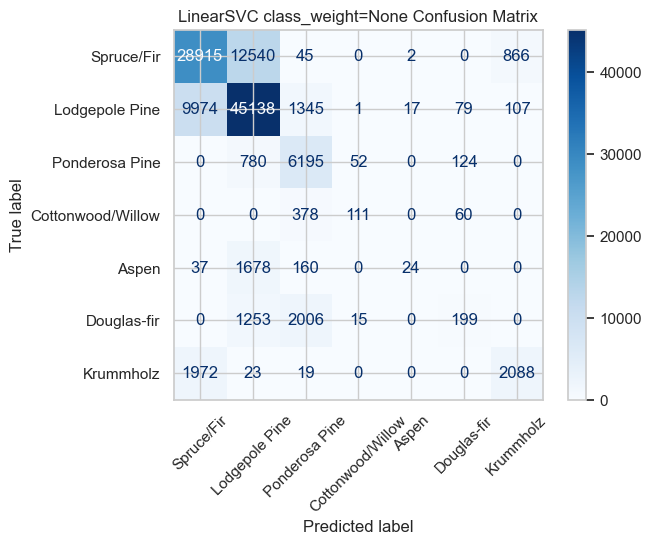

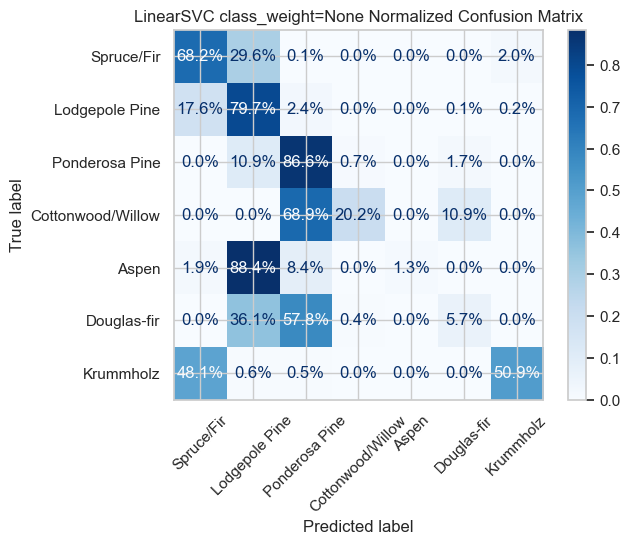

[cache] saved estimator: cache/models/linear_svc_balanced.joblib
[cache] saved predictions: cache/results/linear_svc_balanced.npy
=== LinearSVC class_weight=balanced :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.6970    0.6692    0.6828     42368
   Lodgepole Pine     0.7759    0.6982    0.7350     56661
   Ponderosa Pine     0.6266    0.7157    0.6682      7151
Cottonwood/Willow     0.3520    0.5956    0.4425       549
            Aspen     0.2017    0.3649    0.2598      1899
      Douglas-fir     0.3325    0.4869    0.3951      3473
        Krummholz     0.4897    0.8259    0.6148      4102

         accuracy                         0.6809    116203
        macro avg     0.4965    0.6223    0.5426    116203
     weighted avg     0.7032    0.6809    0.6883    116203



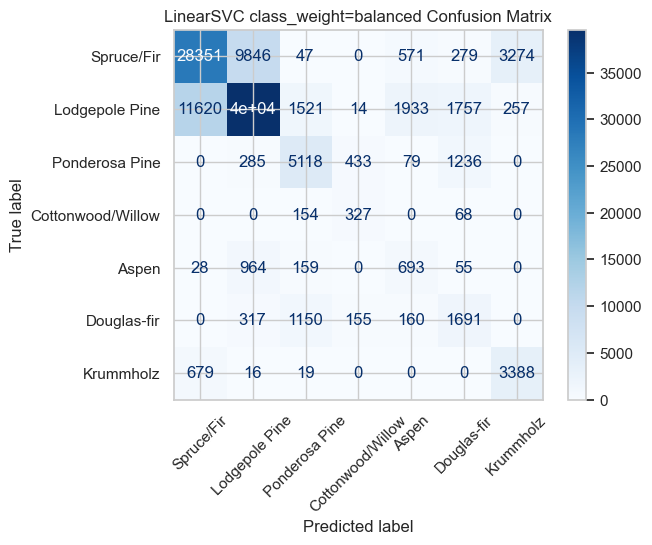

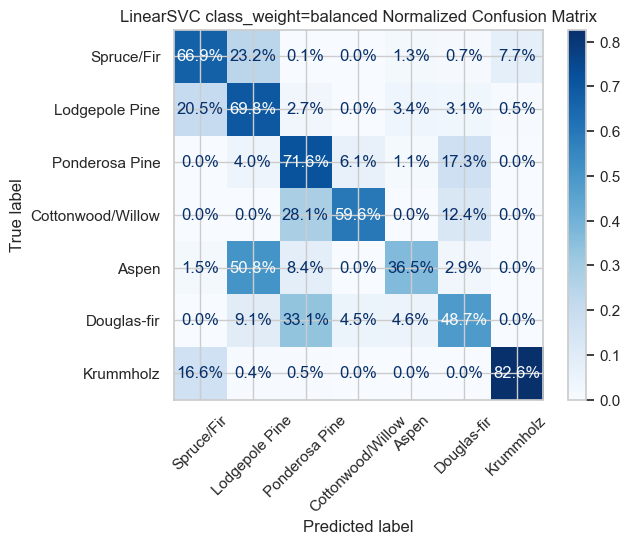

In [15]:
# Source: group-project-jer.ipynb Cells 10, 12, 13
linear_svc_none = _load_or_fit_joblib(
    "linear_svc_unweighted",
    Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(random_state=RANDOM_STATE, class_weight=None)),
    ]),
    X_train,
    y_train,
    "estimator",
 )
y_pred_lsvc_none = _load_or_predict("linear_svc_unweighted", linear_svc_none, X_test)
evaluate_predictions("LinearSVC class_weight=None", y_test, y_pred_lsvc_none, labels, forest_cover_types, model_summaries)

linear_svc_bal = _load_or_fit_joblib(
    "linear_svc_balanced",
    Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(random_state=RANDOM_STATE, class_weight="balanced")),
    ]),
    X_train,
    y_train,
    "estimator",
 )
y_pred_lsvc_bal = _load_or_predict("linear_svc_balanced", linear_svc_bal, X_test)
evaluate_predictions("LinearSVC class_weight=balanced", y_test, y_pred_lsvc_bal, labels, forest_cover_types, model_summaries)
# execution time 38.4s

## Model Type: Decision Tree
Baseline and tuned class-weight-balanced decision tree from Julie's workflow.

[cache] saved estimator: cache/models/decision_tree_baseline_balanced.joblib
[cache] saved predictions: cache/results/decision_tree_baseline_balanced.npy
=== DecisionTree class_weight=balanced (baseline) :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.9348    0.9374    0.9361     42368
   Lodgepole Pine     0.9450    0.9464    0.9457     56661
   Ponderosa Pine     0.9178    0.9217    0.9198      7151
Cottonwood/Willow     0.8063    0.7960    0.8011       549
            Aspen     0.8512    0.8015    0.8256      1899
      Douglas-fir     0.8709    0.8491    0.8599      3473
        Krummholz     0.9433    0.9376    0.9405      4102

         accuracy                         0.9353    116203
        macro avg     0.8956    0.8842    0.8898    116203
     weighted avg     0.9351    0.9353    0.9352    116203



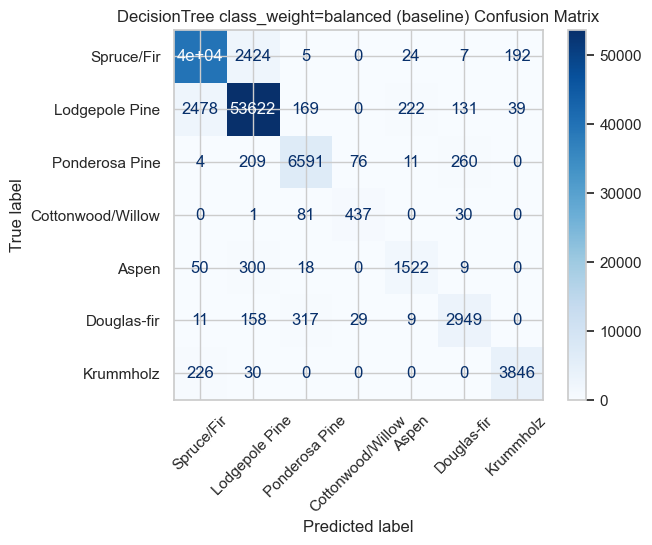

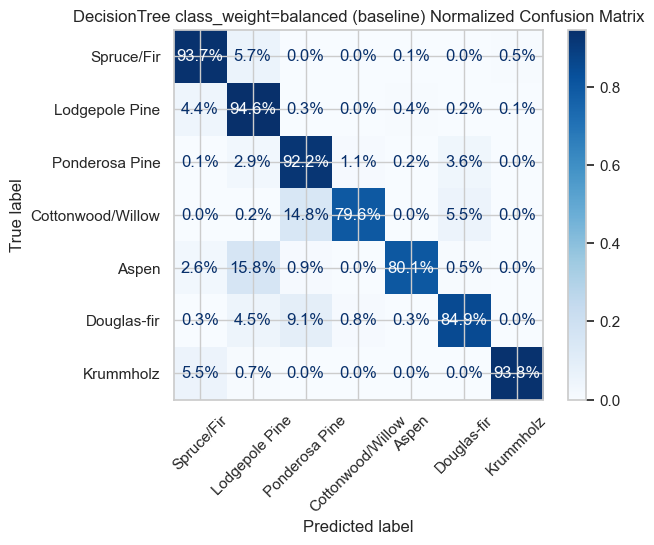

[cache] saved search object: cache/models/decision_tree_random_search_balanced.joblib
[cache] saved params: cache/results/decision_tree_random_search_balanced_best_params.json
[cache] saved predictions: cache/results/decision_tree_tuned_balanced.npy
=== DecisionTree class_weight=balanced (tuned) :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.9374    0.9426    0.9400     42368
   Lodgepole Pine     0.9505    0.9462    0.9483     56661
   Ponderosa Pine     0.9206    0.9225    0.9216      7151
Cottonwood/Willow     0.8405    0.8543    0.8473       549
            Aspen     0.8521    0.8462    0.8491      1899
      Douglas-fir     0.8644    0.8667    0.8656      3473
        Krummholz     0.9474    0.9488    0.9481      4102

         accuracy                         0.9391    116203
        macro avg     0.9019    0.9039    0.9029    116203
     weighted avg     0.9391    0.9391    0.9391    116203



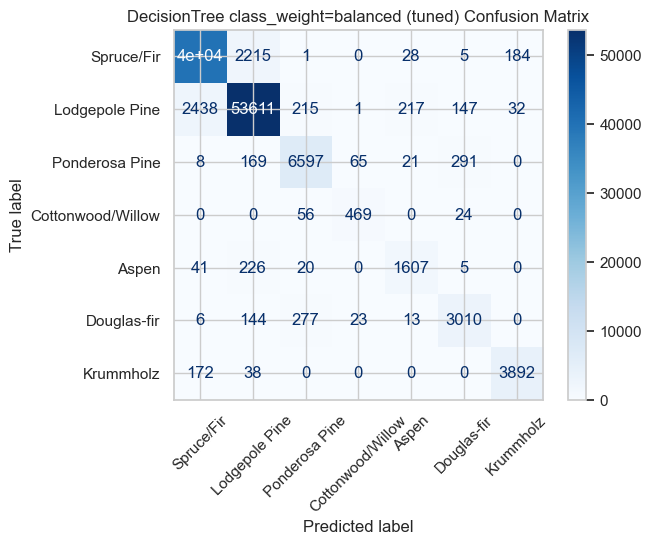

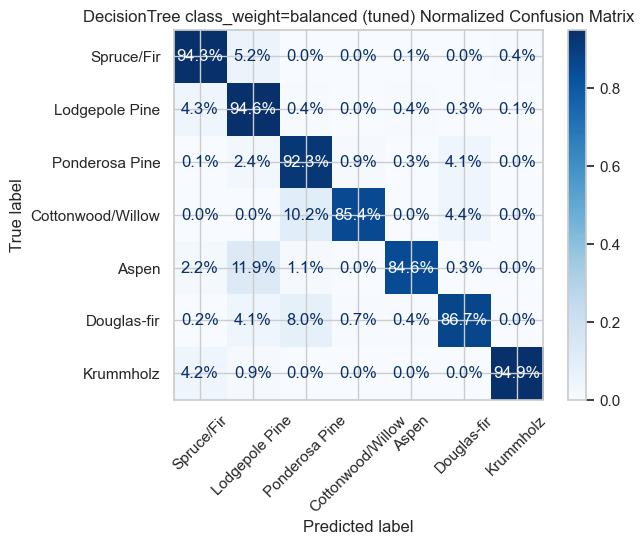

Best tree params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}


In [16]:
# Source: group_project_Julie.ipynb Cells 13 to 18 (Random Forest cells intentionally excluded)
dt_baseline = _load_or_fit_joblib(
    "decision_tree_baseline_balanced",
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    X_train,
    y_train,
    "estimator",
 )
y_pred_dt_base = _load_or_predict("decision_tree_baseline_balanced", dt_baseline, X_test)
evaluate_predictions("DecisionTree class_weight=balanced (baseline)", y_test, y_pred_dt_base, labels, forest_cover_types, model_summaries)

param_dist = {
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

random_search = _load_or_fit_joblib(
    "decision_tree_random_search_balanced",
    RandomizedSearchCV(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="f1_macro",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    X_train,
    y_train,
    "search object",
 )
best_tree = random_search.best_estimator_
_save_result_json("decision_tree_random_search_balanced", "best_params", random_search.best_params_, "params")
y_pred_dt_tuned = _load_or_predict("decision_tree_tuned_balanced", best_tree, X_test)
evaluate_predictions("DecisionTree class_weight=balanced (tuned)", y_test, y_pred_dt_tuned, labels, forest_cover_types, model_summaries)
print("Best tree params:", random_search.best_params_)

## Model Type: Random Forest
Baseline and tuned class-weight-balanced Random Forest from Jingda's workflow.

[cache] saved estimator: cache/models/random_forest_baseline_balanced.joblib
[cache] saved predictions: cache/results/random_forest_baseline_balanced.npy
=== RandomForest class_weight=balanced (baseline) :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.9477    0.9391    0.9434     42368
   Lodgepole Pine     0.9557    0.9465    0.9511     56661
   Ponderosa Pine     0.9151    0.9683    0.9410      7151
Cottonwood/Willow     0.8989    0.8579    0.8779       549
            Aspen     0.8425    0.9242    0.8815      1899
      Douglas-fir     0.8791    0.9257    0.9018      3473
        Krummholz     0.9369    0.9781    0.9571      4102

         accuracy                         0.9448    116203
        macro avg     0.9109    0.9342    0.9220    116203
     weighted avg     0.9452    0.9448    0.9449    116203



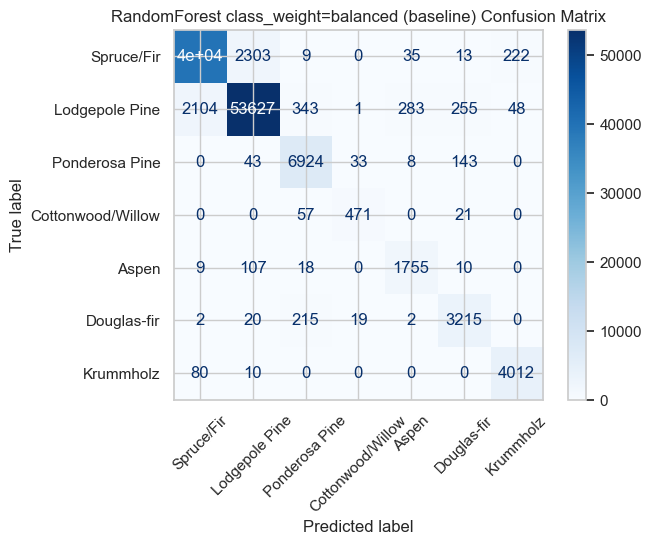

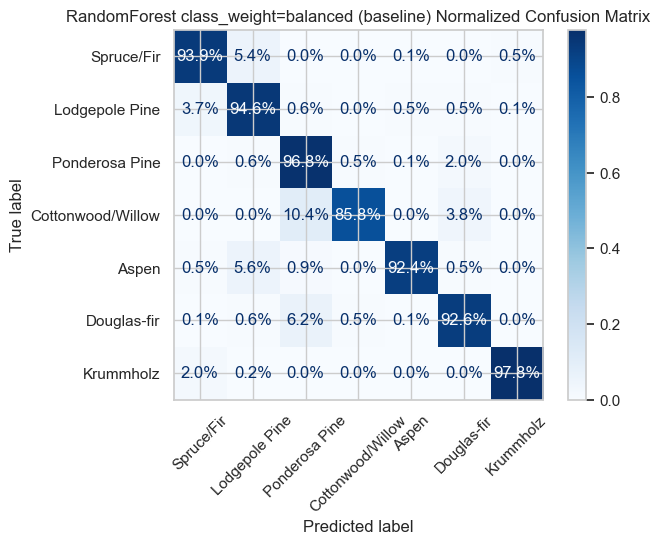

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/Users/janesanchez/anaconda3/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[cache] saved search object: cache/models/random_forest_random_search_balanced.joblib
[cache] saved params: cache/results/random_forest_random_search_balanced_best_params.json
[cache] saved predictions: cache/results/random_forest_tuned_balanced.npy
=== RandomForest class_weight=balanced (tuned) :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.9596    0.9536    0.9566     42368
   Lodgepole Pine     0.9677    0.9571    0.9624     56661
   Ponderosa Pine     0.9305    0.9733    0.9514      7151
Cottonwood/Willow     0.8966    0.8689    0.8825       549
            Aspen     0.8461    0.9494    0.8948      1899
      Douglas-fir     0.9043    0.9418    0.9227      3473
        Krummholz     0.9376    0.9820    0.9593      4102

         accuracy                         0.9567    116203
        macro avg     0.9203    0.9466    0.9328    116203
     weighted avg     0.9572    0.9567    0.9568    116203



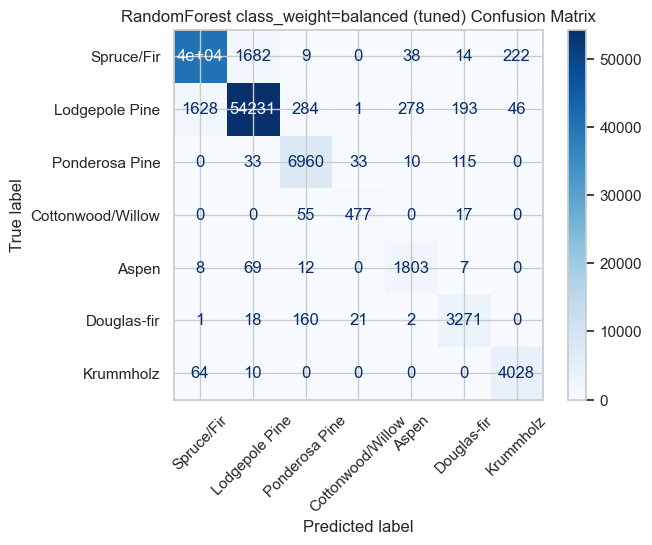

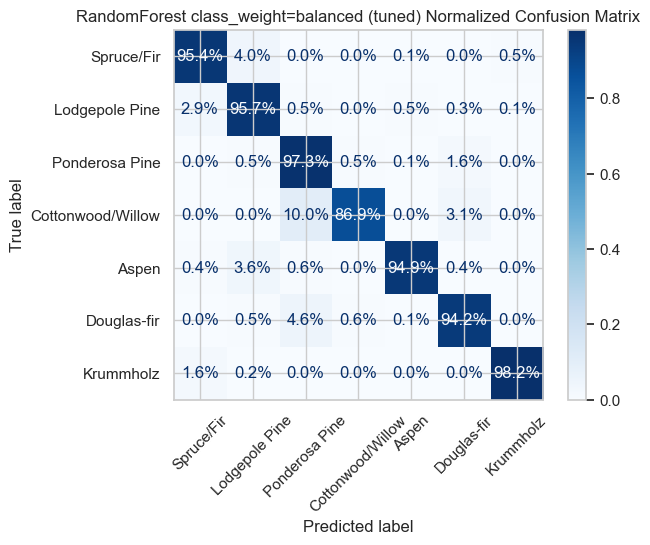

Best RF params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 50}


In [17]:
# Source: group_project_Jingda.ipynb Cells 16, 18, and 22
rf_baseline = _load_or_fit_joblib(
    "random_forest_baseline_balanced",
    RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    ),
    X_train,
    y_train,
    "estimator",
 )
y_pred_rf_base = _load_or_predict("random_forest_baseline_balanced", rf_baseline, X_test)
evaluate_predictions("RandomForest class_weight=balanced (baseline)", y_test, y_pred_rf_base, labels, forest_cover_types, model_summaries)

rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, 40, 50, None],
    "max_features": ["sqrt", 0.3],
    "min_samples_leaf": [1, 2, 4],
}

rf_random_search = _load_or_fit_joblib(
    "random_forest_random_search_balanced",
    RandomizedSearchCV(
        estimator=RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=3,
        ),
        param_distributions=rf_param_dist,
        n_iter=15,
        scoring="f1_macro",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=3,
        verbose=1,
    ),
    X_train,
    y_train,
    "search object",
 )

best_rf = rf_random_search.best_estimator_
_save_result_json("random_forest_random_search_balanced", "best_params", rf_random_search.best_params_, "params")
y_pred_rf_tuned = _load_or_predict("random_forest_tuned_balanced", best_rf, X_test)
evaluate_predictions("RandomForest class_weight=balanced (tuned)", y_test, y_pred_rf_tuned, labels, forest_cover_types, model_summaries)
print("Best RF params:", rf_random_search.best_params_)

## Model Type: RBF SVM
Tuned RBF-kernel SVC using grid search from Jeremy's workflow.

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[cache] saved search object: cache/models/svc_rbf_grid_search_balanced.joblib
[cache] saved params: cache/results/svc_rbf_grid_search_balanced_best_params.json
[cache] saved predictions: cache/results/svc_rbf_tuned_balanced.npy
=== SVC RBF class_weight=balanced (tuned) :: Classification Report ===
                   precision    recall  f1-score   support

       Spruce/Fir     0.8046    0.8016    0.8031     42368
   Lodgepole Pine     0.8673    0.7618    0.8111     56661
   Ponderosa Pine     0.8039    0.8151    0.8095      7151
Cottonwood/Willow     0.6697    0.8051    0.7312       549
            Aspen     0.3025    0.8815    0.4505      1899
      Douglas-fir     0.5570    0.8327    0.6675      3473
        Krummholz     0.6965    0.9481    0.8030      4102

         accuracy                         0.7905    116203
        macro avg     0.6716    0.8351    0.7251    116203
     weighted avg     0.8151    0.7905    0.7973 

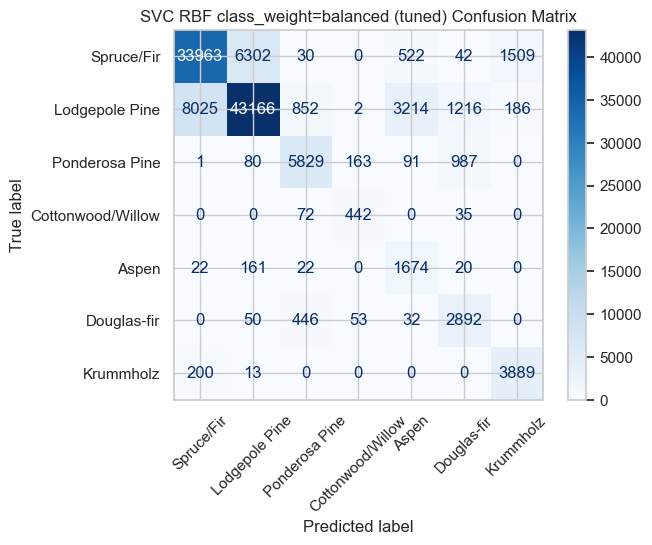

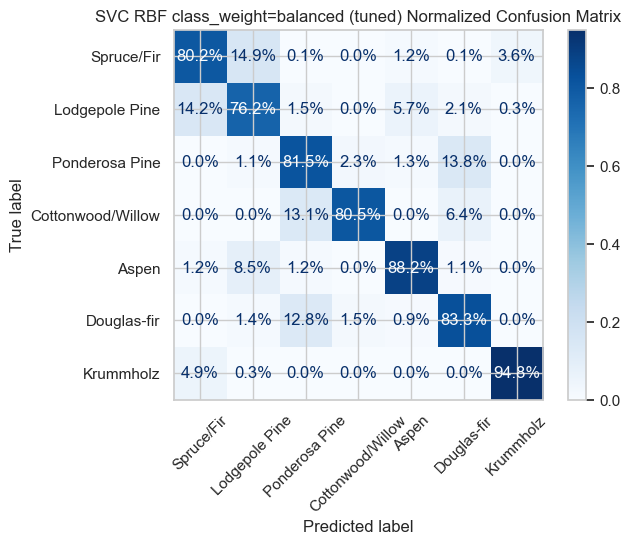

Best RBF params: {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}


In [18]:
# Source: group-project-jer.ipynb Cells 15, 25, 28, 29
n = 50000
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_train, y_train, train_size=n, test_size=n, random_state=RANDOM_STATE, stratify=y_train
)

grid_search = _load_or_fit_joblib(
    "svc_rbf_grid_search_balanced",
    GridSearchCV(
        estimator=Pipeline([
            ("preprocessor", preprocessor),
            ("svc", SVC(random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        param_grid={
            "svc__C": [0.1, 1, 10],
            "svc__gamma": [0.001, 0.01, 0.1],
            "svc__kernel": ["rbf"],
        },
        scoring="f1_macro",
        cv=3,
        n_jobs=3,
        verbose=1,
    ),
    X_train_subset,
    y_train_subset,
    "search object",
 )

best_rbf = grid_search.best_estimator_
_save_result_json("svc_rbf_grid_search_balanced", "best_params", grid_search.best_params_, "params")
y_pred_rbf = _load_or_predict("svc_rbf_tuned_balanced", best_rbf, X_test)
evaluate_predictions("SVC RBF class_weight=balanced (tuned)", y_test, y_pred_rbf, labels, forest_cover_types, model_summaries)
print("Best RBF params:", grid_search.best_params_)

## Model Type: Neural Network
Residual-style dense neural network from Jane's workflow.

[<KerasTensor shape=(None, 54), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_7>]
Epoch 1/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5475 - loss: 3.2753 - val_accuracy: 0.6257 - val_loss: 0.8533 - learning_rate: 0.0010
Epoch 2/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6170 - loss: 2.2665 - val_accuracy: 0.6627 - val_loss: 0.7872 - learning_rate: 0.0010
Epoch 3/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6406 - loss: 2.0613 - val_accuracy: 0.6694 - val_loss: 0.7659 - learning_rate: 0.0010
Epoch 4/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6552 - loss: 1.9504 - val_accuracy: 0.6871 - val_loss: 0.7299 - learning_rate: 0.0010
Epoch 5/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6678 - loss: 1.8617 - val_accuracy: 0.6911 - val_loss: 0.7172 - learning_rate: 0.0010
Epoch 6/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 

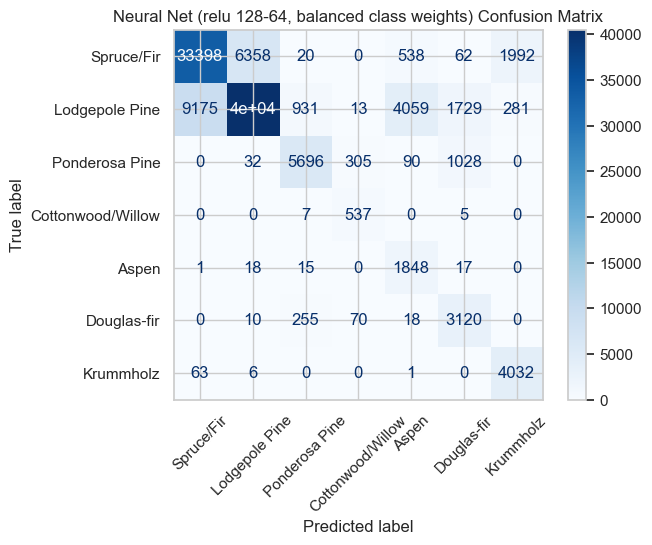

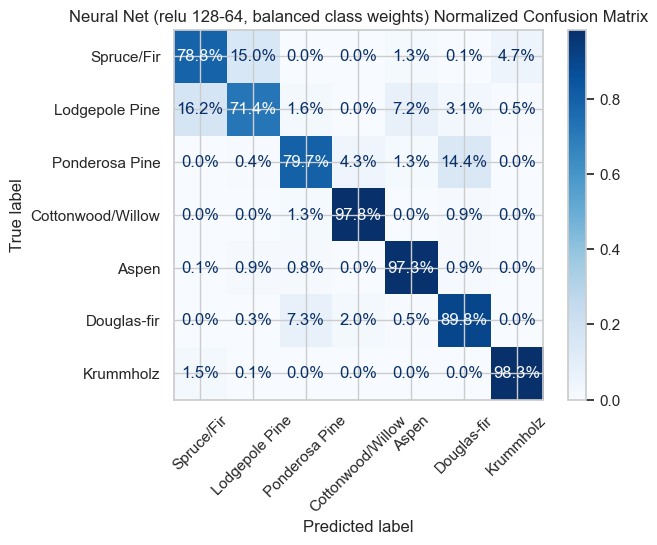

[<KerasTensor shape=(None, 54), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>]
Epoch 1/110
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6303 - loss: 2.2869 - val_accuracy: 0.6990 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 2/110
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6996 - loss: 1.6993 - val_accuracy: 0.7444 - val_loss: 0.6145 - learning_rate: 0.0010
Epoch 3/110
454/454 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7313 - loss: 1.4715 - val_accuracy: 0.7685 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 4/110
454/454 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7551 - loss: 1.3147 - val_accuracy: 0.7842 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 5/110
454/454 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7727 - loss: 1.2161 - val_accuracy: 0.8049 - val_loss: 0.4787 - learning_rate: 0.0010
Epoch 6/110
454/454 ━━━━━━━━━━━━━━━━━

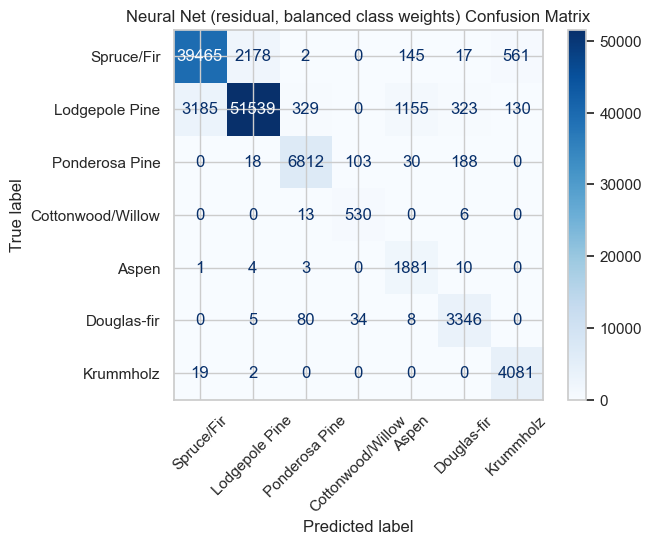

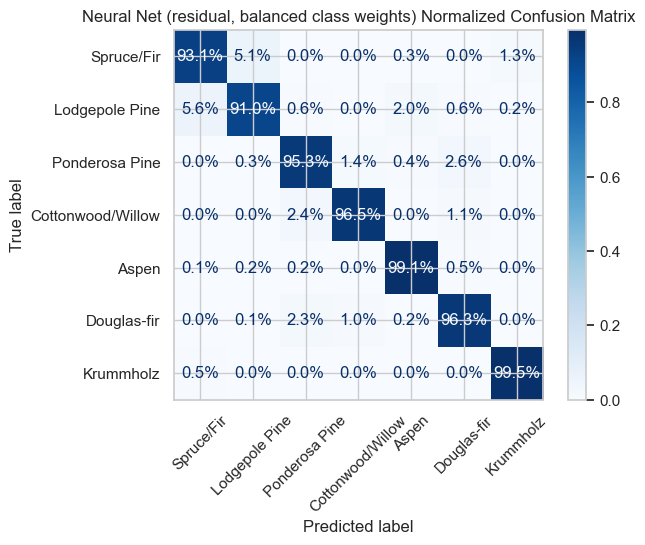

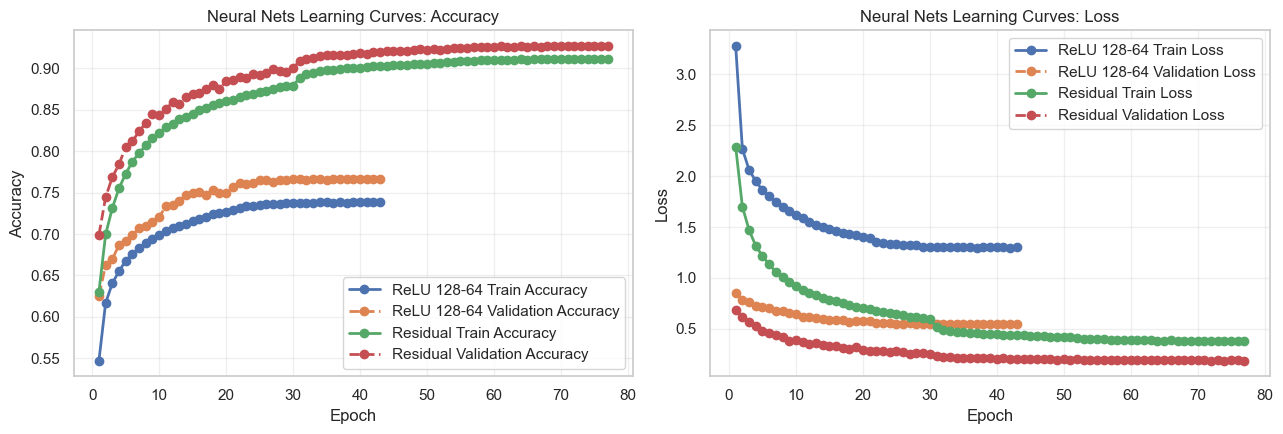

In [19]:
# Source: group-project-jane-neural.ipynb Cells 4 to 8 and 9 to 11
classes = np.arange(7)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_nn)
scaled_weights = class_weights / np.min(class_weights)
class_weight_dict = dict(zip(classes, scaled_weights))

class_counts = np.bincount(y_train_nn)
class_proportions = class_counts / len(y_train_nn)
initial_biases = np.log(class_proportions + 1e-7)


def _valid_history(history_dict_local):
    needed = {"accuracy", "val_accuracy", "loss", "val_loss"}
    return isinstance(history_dict_local, dict) and needed.issubset(history_dict_local.keys())


def build_neural_net_residual(input_dim, initial_biases_vec):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation="swish")(inputs)
    x = layers.BatchNormalization()(x)

    res1 = layers.Dense(512, activation="swish")(x)
    res1 = layers.BatchNormalization()(res1)
    res1 = layers.Dropout(0.3)(res1)
    x = layers.add([x, res1])

    res2 = layers.Dense(512, activation="swish")(x)
    res2 = layers.BatchNormalization()(res2)
    res2 = layers.Dropout(0.3)(res2)
    x = layers.add([x, res2])

    x = layers.Dense(256, activation="swish")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(
        7,
        activation="softmax",
        bias_initializer=initial_biases_vec,
    )(x)
    return keras.Model(inputs, outputs)


def build_neural_net_relu(input_dim, initial_biases_vec):
    init = tf.initializers.he_normal()
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu", kernel_initializer=init),
        keras.layers.BatchNormalization(trainable=True, scale=True, center=True),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu", kernel_initializer=init),
        keras.layers.BatchNormalization(trainable=True, scale=True, center=True),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(7, activation="softmax", kernel_initializer=init, bias_initializer=initial_biases_vec),
    ])
    return model


def _fit_and_save_history(model, model_key, epochs, batch_size):
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.99)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
    )

    print(model.inputs)
    print(model.outputs)

    history = model.fit(
        X_train_nn,
        y_train_nn,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        validation_data=(X_test_nn, y_test_nn),
        class_weight=class_weight_dict,
    )
    history_dict_local = history.history

    model_path = _cache_path(MODEL_CACHE_DIR, model_key, ".keras")
    model.save(model_path)
    _save_result_json(model_key, "history", history_dict_local, "training history")
    return history_dict_local


def train_or_load_neural_model(model_key, build_fn, epochs, batch_size):
    model_path = _cache_path(MODEL_CACHE_DIR, model_key, ".keras")
    history_path = _result_json_path(model_key, "history")
    history_dict = _load_json(history_path) if history_path.exists() else None

    if model_path.exists():
        print(f"[cache] loading neural model: {model_path}")
        model = keras.models.load_model(model_path)
        if not _valid_history(history_dict):
            print(f"[cache] history missing or invalid for {model_key}; retraining to regenerate history")
            history_dict = _fit_and_save_history(model, model_key, epochs, batch_size)
    else:
        K.clear_session()
        model = build_fn(X_train_nn.shape[1], keras.initializers.Constant(initial_biases))
        history_dict = _fit_and_save_history(model, model_key, epochs, batch_size)

    prob_path = _cache_path(RESULTS_CACHE_DIR, f"{model_key}_pred_probs", ".npy")
    if prob_path.exists():
        y_pred_probs = np.load(prob_path, allow_pickle=False)
        if len(y_pred_probs) != len(X_test_nn):
            print(f"[cache] prediction length mismatch for {model_key}, recomputing")
            y_pred_probs = model.predict(X_test_nn)
            np.save(prob_path, y_pred_probs)
    else:
        y_pred_probs = model.predict(X_test_nn)
        np.save(prob_path, y_pred_probs)
        print(f"[cache] saved neural probabilities: {prob_path}")

    y_pred = np.argmax(y_pred_probs, axis=1) + 1
    return model, history_dict, y_pred


nn_model_relu, history_dict_relu, y_pred_nn_relu = train_or_load_neural_model(
    model_key="neural_net_relu_balanced",
    build_fn=build_neural_net_relu,
    epochs=500,
    batch_size=1024,
 )
evaluate_predictions(
    "Neural Net (relu 128-64, balanced class weights)",
    y_test,
    y_pred_nn_relu,
    labels,
    forest_cover_types,
    model_summaries,
 )

nn_model, history_dict, y_pred_nn = train_or_load_neural_model(
    model_key="neural_net_balanced",
    build_fn=build_neural_net_residual,
    epochs=110,
    batch_size=1024,
 )
evaluate_predictions(
    "Neural Net (residual, balanced class weights)",
    y_test,
    y_pred_nn,
    labels,
    forest_cover_types,
    model_summaries,
 )

plot_histories = []
if _valid_history(history_dict_relu):
    plot_histories.append(("ReLU 128-64", history_dict_relu))
else:
    print("[plot] ReLU history missing accuracy/loss keys; skipping ReLU curves")

if _valid_history(history_dict):
    plot_histories.append(("Residual", history_dict))
else:
    print("[plot] Residual history missing accuracy/loss keys; skipping residual curves")

if plot_histories:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for model_label, hist in plot_histories:
        epochs_axis = np.arange(1, len(hist["accuracy"]) + 1)
        axes[0].plot(epochs_axis, hist["accuracy"], marker="o", linewidth=2, label=f"{model_label} Train Accuracy")
        axes[0].plot(epochs_axis, hist["val_accuracy"], marker="o", linewidth=2, linestyle="--", label=f"{model_label} Validation Accuracy")

        axes[1].plot(epochs_axis, hist["loss"], marker="o", linewidth=2, label=f"{model_label} Train Loss")
        axes[1].plot(epochs_axis, hist["val_loss"], marker="o", linewidth=2, linestyle="--", label=f"{model_label} Validation Loss")

    axes[0].set_title("Neural Nets Learning Curves: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Neural Nets Learning Curves: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("[plot] No usable history found for either neural model. Re-train models to regenerate history JSON.")

All model summary metrics


,Model,Accuracy,Macro Recall,Macro F1,Weighted F1
7,RandomForest class_weight=balanced (tuned),0.956714,0.946589,0.932808,0.956811
6,RandomForest class_weight=balanced (baseline),0.944812,0.934233,0.921951,0.944899
5,DecisionTree class_weight=balanced (tuned),0.939055,0.903897,0.902864,0.939067
10,"Neural Net (residual, balanced class weights)",0.926430,0.958272,0.891994,0.927676
4,DecisionTree class_weight=balanced (baseline),0.935286,0.884234,0.889800,0.935199
8,SVC RBF class_weight=balanced (tuned),0.790470,0.835140,0.725130,0.797257
9,"Neural Net (relu 128-64, balanced class weights)",0.766796,0.875957,0.711284,0.775154
3,LinearSVC class_weight=balanced,0.680938,0.622347,0.542598,0.688286
0,LogisticRegression class_weight=None,0.723536,0.509756,0.530642,0.713902
1,LogisticRegression class_weight=balanced,0.599012,0.709271,0.506867,0.627815


Best/Tuned Model Summary (one best result per model family)


,Model Family,Model,Accuracy,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,LogisticRegression class_weight=None,0.723536,0.509756,0.530642,0.713902
1,Linear SVC,LinearSVC class_weight=balanced,0.680938,0.622347,0.542598,0.688286
2,Decision Tree,DecisionTree class_weight=balanced (tuned),0.939055,0.903897,0.902864,0.939067
3,Random Forest,RandomForest class_weight=balanced (tuned),0.956714,0.946589,0.932808,0.956811
4,RBF SVC,SVC RBF class_weight=balanced (tuned),0.790470,0.835140,0.725130,0.797257
5,Neural Net,"Neural Net (residual, balanced class weights)",0.926430,0.958272,0.891994,0.927676


Detailed metrics by model and cover type


...

Side-by-side F1 by Cover Type (rows) and model (columns)


Model,LogisticRegression class_weight=None,LogisticRegression class_weight=balanced,LinearSVC class_weight=None,LinearSVC class_weight=balanced,DecisionTree class_weight=balanced (baseline),DecisionTree class_weight=balanced (tuned),RandomForest class_weight=balanced (baseline),RandomForest class_weight=balanced (tuned),SVC RBF class_weight=balanced (tuned),"Neural Net (relu 128-64, balanced class weights)","Neural Net (residual, balanced class weights)"
CoverType,,,,,,,,,,,
Spruce/Fir,0.7040,0.6720,0.6945,0.6828,0.9361,0.9400,0.9434,0.9566,0.8031,0.7858,0.9282
Lodgepole Pine,0.7722,0.6281,0.7646,0.7350,0.9457,0.9483,0.9511,0.9624,0.8111,0.7816,0.9336
Ponderosa Pine,0.7351,0.6243,0.7162,0.6682,0.9198,0.9216,0.9410,0.9514,0.8095,0.8094,0.9468
Cottonwood/Willow,0.5069,0.4360,0.3049,0.4425,0.8011,0.8473,0.8779,0.8825,0.7312,0.7286,0.8717
Aspen,0.0092,0.1833,0.0247,0.2598,0.8256,0.8491,0.8815,0.8948,0.4505,0.4372,0.7351
Douglas-fir,0.3531,0.4481,0.1011,0.3951,0.8599,0.8656,0.9018,0.9227,0.6675,0.6614,0.9089
Krummholz,0.6340,0.5561,0.5830,0.6148,0.9405,0.9481,0.9571,0.9593,0.8030,0.7749,0.9198


Side-by-side Recall by Cover Type (rows) and model (columns)


Model,LogisticRegression class_weight=None,LogisticRegression class_weight=balanced,LinearSVC class_weight=None,LinearSVC class_weight=balanced,DecisionTree class_weight=balanced (baseline),DecisionTree class_weight=balanced (tuned),RandomForest class_weight=balanced (baseline),RandomForest class_weight=balanced (tuned),SVC RBF class_weight=balanced (tuned),"Neural Net (relu 128-64, balanced class weights)","Neural Net (residual, balanced class weights)"
CoverType,,,,,,,,,,,
Spruce/Fir,0.6972,0.6636,0.6825,0.6692,0.9374,0.9426,0.9391,0.9536,0.8016,0.7883,0.9315
Lodgepole Pine,0.7999,0.5215,0.7966,0.6982,0.9464,0.9462,0.9465,0.9571,0.7618,0.7143,0.9096
Ponderosa Pine,0.8018,0.5636,0.8663,0.7157,0.9217,0.9225,0.9683,0.9733,0.8151,0.7965,0.9526
Cottonwood/Willow,0.4335,0.8871,0.2022,0.5956,0.7960,0.8543,0.8579,0.8689,0.8051,0.9781,0.9654
Aspen,0.0047,0.7788,0.0126,0.3649,0.8015,0.8462,0.9242,0.9494,0.8815,0.9731,0.9905
Douglas-fir,0.2741,0.6602,0.0573,0.4869,0.8491,0.8667,0.9257,0.9418,0.8327,0.8984,0.9634
Krummholz,0.5570,0.8901,0.5090,0.8259,0.9376,0.9488,0.9781,0.9820,0.9481,0.9829,0.9949


,Best Model (F1),Best F1
CoverType,,
Spruce/Fir,RandomForest class_weight=balanced (tuned),0.9566
Lodgepole Pine,RandomForest class_weight=balanced (tuned),0.9624
Ponderosa Pine,RandomForest class_weight=balanced (tuned),0.9514
Cottonwood/Willow,RandomForest class_weight=balanced (tuned),0.8825
Aspen,RandomForest class_weight=balanced (tuned),0.8948
Douglas-fir,RandomForest class_weight=balanced (tuned),0.9227
Krummholz,RandomForest class_weight=balanced (tuned),0.9593


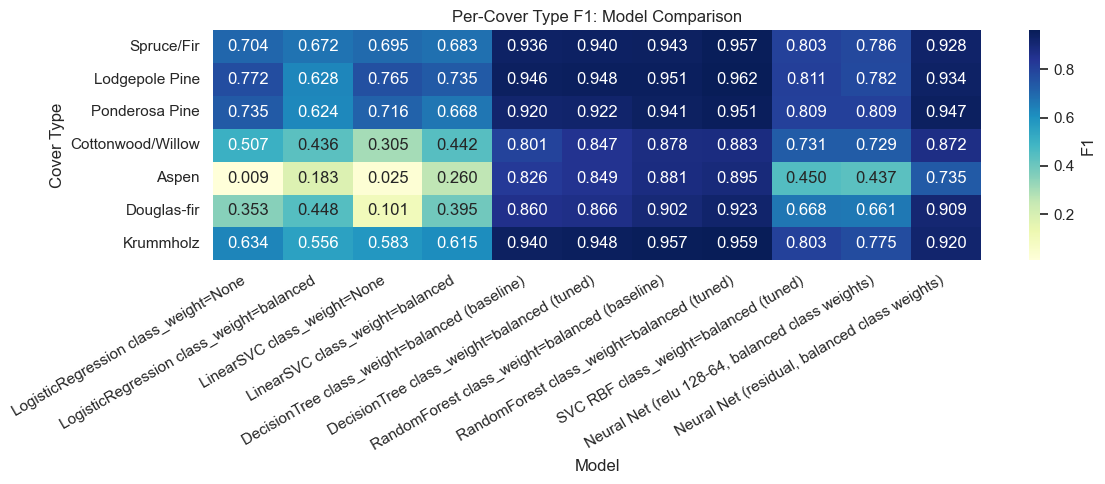

In [20]:
# Unified reporting cell: model-level summary + per-class comparison
model_summary_df = pd.DataFrame(model_summaries)
model_summary_df = model_summary_df.sort_values(by=["Macro F1", "Macro Recall"], ascending=False)

model_prediction_map = {
    "LogisticRegression class_weight=None": globals().get("y_pred_log_un"),
    "LogisticRegression class_weight=balanced": globals().get("y_pred_log"),
    "LinearSVC class_weight=None": globals().get("y_pred_lsvc_none"),
    "LinearSVC class_weight=balanced": globals().get("y_pred_lsvc_bal"),
    "DecisionTree class_weight=balanced (baseline)": globals().get("y_pred_dt_base"),
    "DecisionTree class_weight=balanced (tuned)": globals().get("y_pred_dt_tuned"),
    "RandomForest class_weight=balanced (baseline)": globals().get("y_pred_rf_base"),
    "RandomForest class_weight=balanced (tuned)": globals().get("y_pred_rf_tuned"),
    "SVC RBF class_weight=balanced (tuned)": globals().get("y_pred_rbf"),
    "Neural Net (relu 128-64, balanced class weights)": globals().get("y_pred_nn_relu"),
    "Neural Net (residual, balanced class weights)": globals().get("y_pred_nn"),
}

model_class_rows = []

for model_name, y_pred_model in model_prediction_map.items():
    if y_pred_model is None:
        continue

    report = classification_report(
        y_test,
        y_pred_model,
        labels=labels,
        target_names=forest_cover_types,
        output_dict=True,
        zero_division=0,
    )

    for class_name in forest_cover_types:
        class_stats = report.get(class_name)
        if class_stats is None:
            continue

        model_class_rows.append(
            {
                "Model": model_name,
                "CoverType": class_name,
                "Precision": class_stats["precision"],
                "Recall": class_stats["recall"],
                "F1": class_stats["f1-score"],
                "Support": int(class_stats["support"]),
            }
        )

model_class_df = pd.DataFrame(model_class_rows)

if model_summary_df.empty and model_class_df.empty:
    print("No model summaries or predictions found yet. Run model cells first.")
else:
    if not model_summary_df.empty:
        print("All model summary metrics")
        display(model_summary_df)

        summary_work = model_summary_df.copy()
        summary_work["Model Family"] = np.select(
            [
                summary_work["Model"].str.contains("Logistic", case=False, na=False),
                summary_work["Model"].str.contains("LinearSVC", case=False, na=False),
                summary_work["Model"].str.contains("DecisionTree", case=False, na=False),
                summary_work["Model"].str.contains("RandomForest", case=False, na=False),
                summary_work["Model"].str.contains("SVC RBF|SVC", case=False, na=False),
                summary_work["Model"].str.contains("Neural", case=False, na=False),
            ],
            ["Logistic Regression", "Linear SVC", "Decision Tree", "Random Forest", "RBF SVC", "Neural Net"],
            default="Other",
        )

        best_per_family_df = (
            summary_work.sort_values(by=["Model Family", "Macro F1", "Macro Recall"], ascending=[True, False, False])
            .groupby("Model Family", as_index=False)
            .first()
        )

        family_order = ["Logistic Regression", "Linear SVC", "Decision Tree", "Random Forest", "RBF SVC", "Neural Net"]
        best_per_family_df["Model Family"] = pd.Categorical(
            best_per_family_df["Model Family"], categories=family_order, ordered=True
        )
        best_per_family_df = best_per_family_df.sort_values("Model Family")

        best_per_family_df = best_per_family_df[[
            "Model Family", "Model", "Accuracy", "Macro Recall", "Macro F1", "Weighted F1"
        ]].reset_index(drop=True)

        print("Best/Tuned Model Summary (one best result per model family)")
        display(best_per_family_df)
    else:
        print("No model summary rows found yet.")

    if model_class_df.empty:
        print("No model predictions found yet. Run model cells first.")
    else:
        model_class_df = model_class_df.sort_values(["Model", "CoverType"]).reset_index(drop=True)

        print("Detailed metrics by model and cover type")
        display(model_class_df.round({"Precision": 4, "Recall": 4, "F1": 4}))

        # Class-first side-by-side comparison (easy model comparison per class)
        model_order = [
            "LogisticRegression class_weight=None",
            "LogisticRegression class_weight=balanced",
            "LinearSVC class_weight=None",
            "LinearSVC class_weight=balanced",
            "DecisionTree class_weight=balanced (baseline)",
            "DecisionTree class_weight=balanced (tuned)",
            "RandomForest class_weight=balanced (baseline)",
            "RandomForest class_weight=balanced (tuned)",
            "SVC RBF class_weight=balanced (tuned)",
            "Neural Net (relu 128-64, balanced class weights)",
            "Neural Net (residual, balanced class weights)",
        ]

        class_compare_f1 = (
            model_class_df.pivot(index="CoverType", columns="Model", values="F1")
            .reindex(index=forest_cover_types)
            .reindex(columns=model_order)
        )

        class_compare_recall = (
            model_class_df.pivot(index="CoverType", columns="Model", values="Recall")
            .reindex(index=forest_cover_types)
            .reindex(columns=model_order)
        )

        print("Side-by-side F1 by Cover Type (rows) and model (columns)")
        display(class_compare_f1.round(4))

        print("Side-by-side Recall by Cover Type (rows) and model (columns)")
        display(class_compare_recall.round(4))

        # Best model per class based on F1
        best_model_per_class = class_compare_f1.idxmax(axis=1).rename("Best Model (F1)")
        best_f1_per_class = class_compare_f1.max(axis=1).rename("Best F1")
        display(pd.concat([best_model_per_class, best_f1_per_class.round(4)], axis=1))

        # Visual heatmap for quick scan
        plt.figure(figsize=(12, 5))
        sns.heatmap(class_compare_f1, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "F1"})
        plt.title("Per-Cover Type F1: Model Comparison")
        plt.xlabel("Model")
        plt.ylabel("Cover Type")
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

In [21]:
# Persist summary artifacts for fast reload and reproducibility.
if "model_summary_df" in globals() and not model_summary_df.empty:
    summary_cache_path = RESULTS_CACHE_DIR / "model_summary_metrics.csv"
    model_summary_df.to_csv(summary_cache_path, index=False)
    print(f"[cache] saved summary metrics: {summary_cache_path}")

if "model_class_df" in globals() and not model_class_df.empty:
    class_cache_path = RESULTS_CACHE_DIR / "model_class_metrics.csv"
    model_class_df.to_csv(class_cache_path, index=False)
    print(f"[cache] saved class metrics: {class_cache_path}")

[cache] saved summary metrics: cache/results/model_summary_metrics.csv
[cache] saved class metrics: cache/results/model_class_metrics.csv


## Learning Curves: Classical Models
Combined learning curves for non-neural models using macro F1 and consistent CV settings.

/Users/janesanchez/anaconda3/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[cache] saved learning curves: cache/results/classical_learning_curves.csv


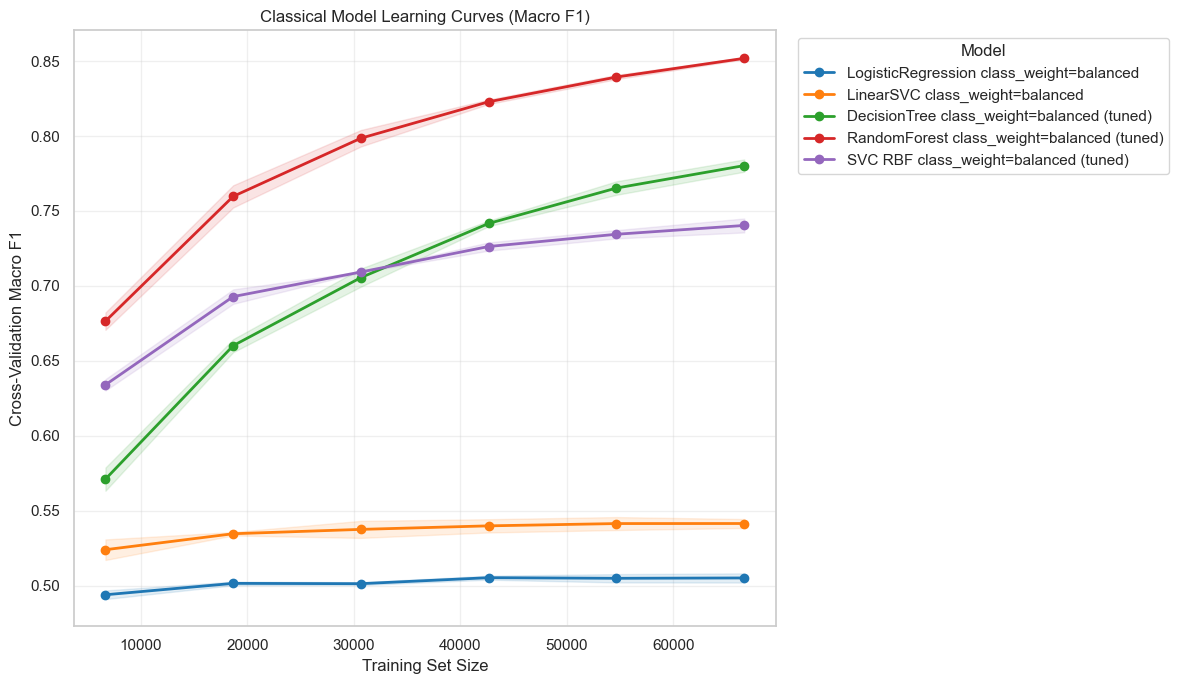

In [22]:
from sklearn.model_selection import learning_curve

# Include both logistic variants plus one representative per remaining classical family.
classical_curve_models = {
    "LogisticRegression class_weight=balanced": logistic_model,
    "LinearSVC class_weight=balanced": linear_svc_bal,
    "DecisionTree class_weight=balanced (tuned)": best_tree,
    "RandomForest class_weight=balanced (tuned)": best_rf,
    "SVC RBF class_weight=balanced (tuned)": best_rbf,
}

learning_curve_model_keys = {
    "LogisticRegression class_weight=balanced": "logistic_regression_balanced",
    "LinearSVC class_weight=balanced": "linear_svc_balanced",
    "DecisionTree class_weight=balanced (tuned)": "decision_tree_random_search_balanced",
    "RandomForest class_weight=balanced (tuned)": "random_forest_random_search_balanced",
    "SVC RBF class_weight=balanced (tuned)": "svc_rbf_grid_search_balanced",
}

curve_cache_csv = RESULTS_CACHE_DIR / "classical_learning_curves.csv"
curve_signature_json = RESULTS_CACHE_DIR / "classical_learning_curves_signature.json"

train_size_grid = np.linspace(0.1, 1.0, 6)
curve_palette = sns.color_palette("tab10", n_colors=len(classical_curve_models))

signature = {
    "train_size_grid": train_size_grid.tolist(),
    "cv": 3,
    "scoring": "f1_macro",
    "sample_rows": int(len(X_train_sample)),
    "sample_target_rows": int(len(y_train_sample)),
    "models": {},
}

for model_name, cache_key in learning_curve_model_keys.items():
    model_path = _cache_path(MODEL_CACHE_DIR, cache_key, ".joblib")
    signature["models"][model_name] = {
        "cache_key": cache_key,
        "mtime_ns": model_path.stat().st_mtime_ns if model_path.exists() else None,
    }

curve_df = None
if curve_cache_csv.exists() and curve_signature_json.exists():
    old_signature = _load_json(curve_signature_json)
    if old_signature == signature:
        curve_df = pd.read_csv(curve_cache_csv)
        print(f"[cache] loading learning curves: {curve_cache_csv}")

if curve_df is None:
    curve_rows = []
    for model_name, estimator in classical_curve_models.items():
        train_sizes, train_scores, val_scores = learning_curve(
            estimator=estimator,
            X=X_train_sample,
            y=y_train_sample,
            train_sizes=train_size_grid,
            cv=3,
            scoring="f1_macro",
            n_jobs=3,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        val_mean = val_scores.mean(axis=1)
        val_std = val_scores.std(axis=1)

        for i in range(len(train_sizes)):
            curve_rows.append({
                "model": model_name,
                "train_size": int(train_sizes[i]),
                "val_mean": float(val_mean[i]),
                "val_std": float(val_std[i]),
            })

    curve_df = pd.DataFrame(curve_rows)
    curve_df.to_csv(curve_cache_csv, index=False)
    _save_json(signature, curve_signature_json)
    print(f"[cache] saved learning curves: {curve_cache_csv}")

plt.figure(figsize=(12, 7))
for color, (model_name, model_df) in zip(curve_palette, curve_df.groupby("model", sort=False)):
    model_df = model_df.sort_values("train_size")
    x = model_df["train_size"].to_numpy()
    y = model_df["val_mean"].to_numpy()
    y_std = model_df["val_std"].to_numpy()

    plt.plot(x, y, marker="o", color=color, linewidth=2, label=model_name)
    plt.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.12)

plt.title("Classical Model Learning Curves (Macro F1)")
plt.xlabel("Training Set Size")
plt.ylabel("Cross-Validation Macro F1")
plt.grid(True, alpha=0.3)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()